In [1]:
import pandas as pd

# 读取DJIA_ret_FH1.csv文件
df = pd.read_csv('./data/mock/DJIA_ret_FH1.csv', header=None)

# 显示数据的基本信息
print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())


数据形状: (1001, 7)

前5行数据:
            0                    1                    2                     3  \
0        Date                  IBM                  JPM                    GS   
1  2020-01-01  0.48559761623884534  -0.3547505230221658  -0.39782249112174306   
2  2020-01-02  0.09859040652992779  -0.1712653590874757    1.4706584193680894   
3  2020-01-03   0.6614646018654585  0.43519472653957475    0.2055216992591531   
4  2020-01-04  -0.7490757479771284  -0.2717259272076901  -0.47117644730200137   

                       4                    5                    6  
0                    CVX                  AXP                   BA  
1  -0.010863480824654454   0.6715561549395958  -0.7380666294210676  
2   0.060409725346746455   0.7848209551200828  0.13334467404292938  
3     0.7591738820813348  -1.0510493613967056  0.19837246533798994  
4     0.9191202890463813  -0.2415417965094343  0.30260962893258636  


In [2]:
"""
GHAR工具函数模块
提供数据加载、预处理、邻接矩阵计算等功能
"""

import numpy as np
import pandas as pd
from sklearn.covariance import GraphicalLassoCV
from sklearn.linear_model import LinearRegression
from os.path import join


# ==================== 数据加载函数 ====================

def load_feature_data(data_path, universe='DJIA'):
    """
    加载波动率特征数据
    
    Args:
        data_path: 数据文件夹路径
        universe: 数据集名称
    Returns:
        feature_df: 波动率特征DataFrame
    """
    feature_df = pd.read_csv(join(data_path, f'{universe}_var_FH1.csv'), index_col=0)
    feature_df.fillna(method="ffill", inplace=True)
    feature_df = feature_df.sort_index(axis=1)
    return feature_df


def load_target_data(data_path, universe='DJIA', horizon=1):
    """
    加载目标波动率数据
    
    Args:
        data_path: 数据文件夹路径
        universe: 数据集名称
        horizon: 预测期数
    Returns:
        vech_df: 目标波动率DataFrame
    """
    var_df = pd.read_csv(join(data_path, f'{universe}_var_FH{horizon}.csv'), index_col=0)
    var_df.fillna(method="ffill", inplace=True)
    var_df = var_df.sort_index(axis=1)
    return var_df


def load_return_data(data_path, universe='DJIA'):
    """
    加载收益率数据（用于计算邻接矩阵）
    
    Args:
        data_path: 数据文件夹路径
        universe: 数据集名称
    Returns:
        ret_df: 收益率DataFrame
    """
    ret_df = pd.read_csv(join(data_path, f'{universe}_ret_FH1.csv'), index_col=0)
    ret_df.fillna(method="ffill", inplace=True)
    ret_df = ret_df.sort_index(axis=1)
    return ret_df


# ==================== HAR特征工程 ====================

def create_har_features(feature_df, target_df, har_lags=[1, 5, 22]):
    """
    创建HAR特征：计算不同滞后期的平均波动率
    
    Args:
        feature_df: 波动率特征DataFrame
        target_df: 目标波动率DataFrame
        har_lags: 滞后期列表 [日频, 周频, 月频]
    
    Returns:
        subdf_dic: 按日期组织的特征字典
        date_l: 日期列表
    """
    subdf_l = []
    
    for target_var in target_df.columns:
        subdf = pd.DataFrame()
        subdf['Target'] = target_df[target_var].copy()
        subdf['Date'] = target_df.index
        subdf['Ticker'] = target_var
        
        # 为每个滞后期创建特征
        indpt_df_l = []
        for lag in har_lags:
            tmp_indpdt_df = 0
            for il in range(1, 1 + lag):
                tmp_indpdt_df += feature_df[target_var].shift(il)
            indpt_df_l.append(tmp_indpdt_df / lag)
        
        # 合并特征
        explain_df = pd.concat(indpt_df_l, axis=1)
        explain_df.columns = ['var+lag%d' % i for i in har_lags]
        
        subdf = pd.merge(subdf, explain_df, left_index=True, right_index=True)
        subdf.replace([np.inf, -np.inf], np.nan, inplace=True)
        subdf.dropna(inplace=True)
        subdf_l.append(subdf)
    
    df = pd.concat(subdf_l)
    df.reset_index(drop=True, inplace=True)
    
    # 按日期组织数据
    date_l = sorted(list(set(df['Date'].tolist())))
    subdf_dic = {date: df[df['Date'] == date] for date in date_l}
    
    print(f'✓ HAR特征创建完成！共 {len(date_l)} 个日期')
    return subdf_dic, date_l


# ==================== 邻接矩阵计算 ====================

def compute_glasso_adjacency(ret_df):
    """
    使用Graphical LASSO计算稀疏邻接矩阵
    
    Args:
        ret_df: 收益率DataFrame
    Returns:
        adj_df: 归一化的邻接矩阵DataFrame
    """
    n = ret_df.shape[1]
    tickers = ret_df.columns
    
    # Graphical LASSO估计
    cov = GraphicalLassoCV().fit(ret_df)
    print(f'  Alpha (正则化参数): {cov.alpha_:.4f}')
    
    # 转换为邻接矩阵
    corr = cov.precision_ != 0
    print(f'  邻接矩阵稀疏度: {corr.mean():.3f}')
    
    # 移除自环
    corr_adj = corr - np.identity(n)
    
    # 对称归一化: D^{-1/2} A D^{-1/2}
    d_sqrt_inv = np.diag(np.sqrt(1 / (corr_adj.sum(1) + 1e-8)))
    adj_normalized = np.dot(np.dot(d_sqrt_inv, corr_adj), d_sqrt_inv)
    
    adj_df = pd.DataFrame(adj_normalized, columns=tickers, index=tickers)
    return adj_df


def create_identity_adjacency(tickers):
    """
    创建单位邻接矩阵（对应HAR模型）
    
    Args:
        tickers: 股票代码列表
    Returns:
        adj_df: 单位矩阵DataFrame
    """
    n = len(tickers)
    adj_df = pd.DataFrame(np.identity(n), index=tickers, columns=tickers)
    return adj_df


def apply_graph_aggregation(subdf_dic, date_l, adj_df_l):
    """
    应用图聚合：将邻接矩阵与特征相乘
    
    Args:
        subdf_dic: 特征字典
        date_l: 日期列表
        adj_df_l: 邻接矩阵列表
    Returns:
        df: 聚合后的特征DataFrame
    """
    new_subdf_l = []
    
    for date in date_l:
        subdf = subdf_dic[date]
        tmp_subdf_l = []
        clms = [i for i in subdf.columns if 'lag' in i]
        
        # 对每个邻接矩阵进行聚合
        for k, adj_df in enumerate(adj_df_l):
            # 矩阵乘法: A @ Features
            aggregated = np.dot(adj_df.values, subdf[clms].values)
            tmp_subdf = pd.DataFrame(
                aggregated, 
                columns=['sec' + str(k) + i for i in clms], 
                index=subdf.index
            )
            tmp_subdf_l.append(tmp_subdf)
        
        # 合并原始列和聚合列
        new_subdf = pd.concat([subdf[['Target', 'Date', 'Ticker']]] + tmp_subdf_l, axis=1)
        new_subdf_l.append(new_subdf)
    
    df = pd.concat(new_subdf_l)
    df.reset_index(drop=True, inplace=True)
    print('✓ 图聚合完成！')
    return df


# ==================== 数据分割 ====================

def split_train_test(df, train_start_date, train_end_date, test_start_date, test_end_date):
    """
    分割训练集和测试集
    
    Args:
        df: 完整数据DataFrame
        train_start_date: 训练开始日期
        train_end_date: 训练结束日期
        test_start_date: 测试开始日期
        test_end_date: 测试结束日期
    
    Returns:
        train_df: 训练集
        test_df: 测试集
    """
    train_df = df[(df['Date'] >= train_start_date) & (df['Date'] < train_end_date)]
    test_df = df[(df['Date'] >= test_start_date) & (df['Date'] < test_end_date)]
    
    print(f'训练集大小: {len(train_df)} 样本')
    print(f'测试集大小: {len(test_df)} 样本')
    
    return train_df, test_df


def df_to_arrays(df, feature_cols):
    """
    将DataFrame转换为numpy数组
    
    Args:
        df: DataFrame
        feature_cols: 特征列名列表
    Returns:
        X: 特征矩阵
        y: 目标向量
    """
    X = df[feature_cols].values
    y = df['Target'].values
    return X, y


# ==================== 模型训练与预测 ====================

def train_har_model(train_X, train_y):
    """
    训练HAR/GHAR线性回归模型
    
    Args:
        train_X: 训练特征
        train_y: 训练目标
    Returns:
        model: 训练好的模型
    """
    model = LinearRegression()
    model.fit(train_X, train_y)
    
    print(f'✓ 模型训练完成')
    print(f'  系数: {model.coef_[:5]}...')  # 只显示前5个
    print(f'  截距: {model.intercept_:.6f}')
    
    return model


def predict_and_adjust(model, test_X, test_df, train_df):
    """
    预测并调整负值预测
    
    Args:
        model: 训练好的模型
        test_X: 测试特征
        test_df: 测试DataFrame
        train_df: 训练DataFrame（用于获取最小值）
    Returns:
        pred_df: 预测结果DataFrame
    """
    # 预测
    predictions = model.predict(test_X)
    
    # 创建预测DataFrame
    pred_df = test_df[['Ticker', 'Date']].copy()
    pred_df['Prediction'] = predictions
    pred_df = pred_df.pivot(index='Date', columns='Ticker', values='Prediction')
    
    print(f'调整前最小预测值: {pred_df.min().min():.6f}')
    
    # 调整负值预测
    for ticker in pred_df.columns:
        ticker_train = train_df[train_df['Ticker'] == ticker]['Target']
        min_val = ticker_train.min()
        pred_df[ticker] = pred_df[ticker].clip(lower=min_val)
    
    print(f'调整后最小预测值: {pred_df.min().min():.6f}')
    
    return pred_df


# ==================== 评估函数 ====================

def evaluate_predictions(pred_df, true_df):
    """
    评估预测结果
    
    Args:
        pred_df: 预测DataFrame
        true_df: 真实值DataFrame
    Returns:
        metrics: 评估指标字典
    """
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    
    # 对齐数据
    common_dates = pred_df.index.intersection(true_df.index)
    common_tickers = pred_df.columns.intersection(true_df.columns)
    
    pred_values = pred_df.loc[common_dates, common_tickers].values.flatten()
    true_values = true_df.loc[common_dates, common_tickers].values.flatten()
    
    # 计算指标
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true_values, pred_values)
    
    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'N_samples': len(pred_values)
    }
    
    print('\n📊 评估结果:')
    for key, val in metrics.items():
        print(f'  {key}: {val:.6f}')
    
    return metrics

In [3]:
import sys
sys.path.append('./GNNHAR')  # 添加路径
import pandas as pd
import numpy as np

# 设置数据路径
DATA_PATH = './data/mock'

In [4]:
# Cell 2: 加载数据
print("=" * 60)
print("步骤1: 加载数据")
print("=" * 60)

feature_df = load_feature_data(DATA_PATH)
target_df = load_target_data(DATA_PATH, horizon=1)
ret_df = load_return_data(DATA_PATH)

print(f"\n特征数据形状: {feature_df.shape}")
print(f"目标数据形状: {target_df.shape}")
print(f"收益率数据形状: {ret_df.shape}")
print(f"\n股票列表: {list(feature_df.columns)}")

步骤1: 加载数据

特征数据形状: (1000, 6)
目标数据形状: (1000, 6)
收益率数据形状: (1000, 6)

股票列表: ['AXP', 'BA', 'CVX', 'GS', 'IBM', 'JPM']


In [5]:
# Cell 3: 创建HAR特征
print("\n" + "=" * 60)
print("步骤2: 创建HAR特征")
print("=" * 60)

subdf_dic, date_l = create_har_features(feature_df, target_df, har_lags=[1, 5, 22])

print(f"\n日期范围: {date_l[0]} 到 {date_l[-1]}")
print(f"总日期数: {len(date_l)}")
print(f"\n前5个日期: {date_l[:5]}")
print(f"后5个日期: {date_l[-5:]}")
print(f"\n示例特征 (第一个日期 {date_l[0]}):")
print(subdf_dic[date_l[0]].head())
print(f"\n示例特征 (中间日期 {date_l[len(date_l)//2]}):")
print(subdf_dic[date_l[len(date_l)//2]].head())
print(f"\n示例特征 (最后日期 {date_l[-1]}):")
print(subdf_dic[date_l[-1]].head())


步骤2: 创建HAR特征
✓ HAR特征创建完成！共 978 个日期

日期范围: 2020-01-23 到 2022-09-26
总日期数: 978

前5个日期: ['2020-01-23', '2020-01-24', '2020-01-25', '2020-01-26', '2020-01-27']
后5个日期: ['2022-09-22', '2022-09-23', '2022-09-24', '2022-09-25', '2022-09-26']

示例特征 (第一个日期 2020-01-23):
        Target        Date Ticker  var+lag1  var+lag5  var+lag22
0     0.324010  2020-01-23    AXP  0.412480  0.281904   0.266776
978   0.267741  2020-01-23     BA  0.233518  0.292797   0.276721
1956  0.224662  2020-01-23    CVX  0.373566  0.327373   0.317906
2934  0.291636  2020-01-23     GS  0.218458  0.305891   0.329003
3912  0.370877  2020-01-23    IBM  0.487050  0.417017   0.365262

示例特征 (中间日期 2021-05-26):
        Target        Date Ticker  var+lag1  var+lag5  var+lag22
489   0.308757  2021-05-26    AXP  0.268743  0.278478   0.300306
1467  0.288716  2021-05-26     BA  0.239084  0.312167   0.294702
2445  0.340401  2021-05-26    CVX  0.432142  0.273146   0.285091
3423  0.304377  2021-05-26     GS  0.366003  0.274862   0.330396


In [6]:
def create_predefined_adjacency(stock_order=['IBM', 'JPM', 'GS', 'CVX', 'AXP', 'BA']):
    """
    创建预定义的邻接矩阵（基于模拟网络结构）
    
    网络结构（根据图片）:
    - IBM (0-hop): 连接到 JPM, GS, BA
    - JPM (1-hop): 连接到 IBM, GS, CVX
    - GS (1-hop): 连接到 IBM, JPM, BA
    - CVX (2-hop): 连接到 JPM, AXP
    - AXP (2-hop): 连接到 CVX, BA
    - BA (2-hop): 连接到 IBM, GS, AXP
    
    Args:
        stock_order: 股票顺序列表
    Returns:
        W: 归一化的邻接矩阵 DataFrame
        A: 原始邻接矩阵 DataFrame
    """
    # 邻接矩阵 A (根据图片的连接关系)
    A = np.array([
        [0, 1, 1, 0, 0, 1],  # IBM -> JPM, GS, BA
        [1, 0, 1, 1, 0, 0],  # JPM -> IBM, GS, CVX
        [1, 1, 0, 0, 0, 1],  # GS -> IBM, JPM, BA
        [0, 1, 0, 0, 1, 0],  # CVX -> JPM, AXP
        [0, 0, 0, 1, 0, 1],  # AXP -> CVX, BA
        [1, 0, 1, 0, 1, 0]   # BA -> IBM, GS, AXP
    ])
    
    # 度矩阵 O = diag(3, 3, 3, 2, 2, 3)
    degrees = A.sum(axis=1)
    O = np.diag(degrees)
    
    # 对称归一化: W = O^{-1/2} A O^{-1/2}
    O_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
    W = O_inv_sqrt @ A @ O_inv_sqrt
    
    # 转换为 DataFrame
    A_df = pd.DataFrame(A, index=stock_order, columns=stock_order)
    W_df = pd.DataFrame(W, index=stock_order, columns=stock_order)
    
    print("原始邻接矩阵 A:")
    print(A_df)
    print(f"\n度矩阵 O: {degrees}")
    print("\n归一化邻接矩阵 W = O^{-1/2} A O^{-1/2}:")
    print(W_df.round(4))
    
    return W_df, A_df


def compute_qlike_loss(y_true, y_pred):
    """
    计算 QLIKE 损失函数
    
    QL = (RV / RV_pred) - log(RV / RV_pred) - 1
    
    Args:
        y_true: 真实值
        y_pred: 预测值
    Returns:
        qlike: QLIKE损失
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)

In [7]:
# Cell 1: 导入并设置
import sys
sys.path.append('./GNNHAR')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 设置数据路径
DATA_PATH = './data/mock'

# 确保股票顺序与邻接矩阵一致
STOCK_ORDER = ['IBM', 'JPM', 'GS', 'CVX', 'AXP', 'BA']

print("=" * 80)
print("模拟数据测试: HAR vs GHAR vs GNNHAR")
print("=" * 80)

模拟数据测试: HAR vs GHAR vs GNNHAR


In [8]:
# Cell 2: 加载数据
print("\n步骤1: 加载数据")
print("-" * 80)

feature_df = load_feature_data(DATA_PATH)
target_df = load_target_data(DATA_PATH, horizon=1)
ret_df = load_return_data(DATA_PATH)

# 确保列顺序一致
feature_df = feature_df[STOCK_ORDER]
target_df = target_df[STOCK_ORDER]
ret_df = ret_df[STOCK_ORDER]

print(f"特征数据形状: {feature_df.shape}")
print(f"目标数据形状: {target_df.shape}")
print(f"股票顺序: {list(feature_df.columns)}")


步骤1: 加载数据
--------------------------------------------------------------------------------
特征数据形状: (1000, 6)
目标数据形状: (1000, 6)
股票顺序: ['IBM', 'JPM', 'GS', 'CVX', 'AXP', 'BA']


In [9]:
# Cell 3: 创建HAR特征
print("\n步骤2: 创建HAR特征")
print("-" * 80)

subdf_dic, date_l = create_har_features(feature_df, target_df, har_lags=[1, 5, 22])

print(f"日期范围: {date_l[0]} 到 {date_l[-1]}")
print(f"总日期数: {len(date_l)}")


步骤2: 创建HAR特征
--------------------------------------------------------------------------------
✓ HAR特征创建完成！共 978 个日期
日期范围: 2020-01-23 到 2022-09-26
总日期数: 978


In [10]:
# Cell 4: 创建预定义的邻接矩阵（基于网络结构）
print("\n步骤3: 创建预定义邻接矩阵")
print("-" * 80)

W_true, A_true = create_predefined_adjacency(STOCK_ORDER)



# 对比：使用GLASSO估计的邻接矩阵
print("\n\n对比: Graphical LASSO估计的邻接矩阵")
print("-" * 80)
train_ret = ret_df.iloc[:600]
W_glasso = compute_glasso_adjacency(train_ret)

print("-" * 80)

print("预定义权重矩阵 W_true:")
print(W_true)
print("\n预定义邻接矩阵 A_true:")
print(A_true)
print("\nGLASSO估计的权重矩阵 W_glasso:")
print(W_glasso)


步骤3: 创建预定义邻接矩阵
--------------------------------------------------------------------------------
原始邻接矩阵 A:
     IBM  JPM  GS  CVX  AXP  BA
IBM    0    1   1    0    0   1
JPM    1    0   1    1    0   0
GS     1    1   0    0    0   1
CVX    0    1   0    0    1   0
AXP    0    0   0    1    0   1
BA     1    0   1    0    1   0

度矩阵 O: [3 3 3 2 2 3]

归一化邻接矩阵 W = O^{-1/2} A O^{-1/2}:
        IBM     JPM      GS     CVX     AXP      BA
IBM  0.0000  0.3333  0.3333  0.0000  0.0000  0.3333
JPM  0.3333  0.0000  0.3333  0.4082  0.0000  0.0000
GS   0.3333  0.3333  0.0000  0.0000  0.0000  0.3333
CVX  0.0000  0.4082  0.0000  0.0000  0.5000  0.0000
AXP  0.0000  0.0000  0.0000  0.5000  0.0000  0.4082
BA   0.3333  0.0000  0.3333  0.0000  0.4082  0.0000


对比: Graphical LASSO估计的邻接矩阵
--------------------------------------------------------------------------------
  Alpha (正则化参数): 0.0280
  邻接矩阵稀疏度: 0.222
--------------------------------------------------------------------------------
预定义权重矩阵 W_true:
 

In [11]:
# Cell 5: 数据分割
print("\n步骤4: 数据分割")
print("-" * 80)

# 使用前600天训练，之后100天测试
train_end_idx = 600
test_end_idx = 700

split_date = date_l[min(train_end_idx, len(date_l)-100)]
test_end_date = date_l[min(test_end_idx, len(date_l)-1)]

print(f"训练期: {date_l[0]} 到 {split_date}")
print(f"测试期: {split_date} 到 {test_end_date}")


步骤4: 数据分割
--------------------------------------------------------------------------------
训练期: 2020-01-23 到 2021-09-14
测试期: 2021-09-14 到 2021-12-23


In [12]:
# Cell 6: 训练和评估函数
def train_and_evaluate_model(subdf_dic, date_l, adj_list, model_name,
                              split_date, test_end_date):
    """
    训练并评估模型
    
    Args:
        subdf_dic: HAR特征字典
        date_l: 日期列表
        adj_list: 邻接矩阵列表
        model_name: 模型名称
        split_date: 训练/测试分割日期
        test_end_date: 测试结束日期
    
    Returns:
        results: 包含预测、真实值和评估指标的字典
    """
    print(f"\n{'='*80}")
    print(f"训练 {model_name} 模型")
    print(f"{'='*80}")
    
    # 应用图聚合
    df_agg = apply_graph_aggregation(subdf_dic, date_l, adj_list)
    
    # 分割数据
    train_df, test_df = split_train_test(
        df_agg, date_l[0], split_date, split_date, test_end_date
    )
    
    # 提取特征
    feature_cols = [col for col in train_df.columns if 'lag' in col]
    print(f"使用 {len(feature_cols)} 个特征")
    
    train_X, train_y = df_to_arrays(train_df, feature_cols)
    test_X, test_y = df_to_arrays(test_df, feature_cols)
    
    # 训练模型
    model = train_har_model(train_X, train_y)
    
    # 预测
    pred_df = predict_and_adjust(model, test_X, test_df, train_df)
    true_df = test_df.pivot(index='Date', columns='Ticker', values='Target')
    
    # 计算评估指标
    pred_values = pred_df.values.flatten()
    true_values = true_df.loc[pred_df.index, pred_df.columns].values.flatten()
    
    mse = mean_squared_error(true_values, pred_values)
    qlike = compute_qlike_loss(true_values, pred_values)
    
    print(f"\n📊 {model_name} 评估结果:")
    print(f"  MSE:   {mse:.6f}")
    print(f"  RMSE:  {np.sqrt(mse):.6f}")
    print(f"  QLIKE: {qlike:.6f}")
    
    # 返回结果
    results = {
        'model_name': model_name,
        'model': model,
        'pred_df': pred_df,
        'true_df': true_df,
        'mse': mse,
        'qlike': qlike,
        'coefficients': model.coef_,
        'intercept': model.intercept_
    }
    
    return results

In [13]:
# Cell 7: 训练 HAR 模型（baseline）
print("\n" + "="*80)
print("模型1: HAR (无邻接矩阵)")
print("="*80)

# HAR使用单位矩阵
adj_identity = create_identity_adjacency(STOCK_ORDER)
results_har = train_and_evaluate_model(
    subdf_dic, date_l, [adj_identity], 'HAR',
    split_date, test_end_date
)


模型1: HAR (无邻接矩阵)

训练 HAR 模型


✓ 图聚合完成！
训练集大小: 3600 样本
测试集大小: 600 样本
使用 3 个特征
✓ 模型训练完成
  系数: [0.02978392 0.01505077 0.52787895]...
  截距: 0.139807
调整前最小预测值: 0.269668
调整后最小预测值: 0.269668

📊 HAR 评估结果:
  MSE:   0.008105
  RMSE:  0.090030
  QLIKE: 0.073745


In [14]:
# Cell 8: 训练 GHAR 模型（使用真实邻接矩阵）
print("\n" + "="*80)
print("模型2: GHAR (真实邻接矩阵)")
print("="*80)

# GHAR使用单位矩阵 + 真实邻接矩阵
results_ghar_true = train_and_evaluate_model(
    subdf_dic, date_l, [adj_identity, W_true], 'GHAR (True Adjacency)',
    split_date, test_end_date
)


模型2: GHAR (真实邻接矩阵)

训练 GHAR (True Adjacency) 模型
✓ 图聚合完成！
训练集大小: 3600 样本
测试集大小: 600 样本
使用 6 个特征
✓ 模型训练完成
  系数: [0.03048452 0.01609292 0.49041938 0.01638279 0.09453144]...
  截距: 0.114778
调整前最小预测值: 0.274616
调整后最小预测值: 0.274616

📊 GHAR (True Adjacency) 评估结果:
  MSE:   0.008092
  RMSE:  0.089956
  QLIKE: 0.073697


In [15]:
# Cell 9: 训练 GHAR 模型（使用错误的GLASSO邻接矩阵）
print("\n" + "="*80)
print("模型3: GHAR (GLASSO邻接矩阵 - 错误)")
print("="*80)

results_ghar_glasso = train_and_evaluate_model(
    subdf_dic, date_l, [adj_identity, W_glasso], 'GHAR (GLASSO Adjacency)',
    split_date, test_end_date
)


模型3: GHAR (GLASSO邻接矩阵 - 错误)

训练 GHAR (GLASSO Adjacency) 模型
✓ 图聚合完成！
训练集大小: 3600 样本
测试集大小: 600 样本
使用 6 个特征
✓ 模型训练完成
  系数: [ 0.02990998  0.0141332   0.52807839  0.0155456  -0.09457956]...
  截距: 0.140356
调整前最小预测值: 0.270062
调整后最小预测值: 0.270062

📊 GHAR (GLASSO Adjacency) 评估结果:
  MSE:   0.008099
  RMSE:  0.089994
  QLIKE: 0.073715


In [16]:
# Cell 9.5: 测试随机邻接矩阵（发现效果居然比真实邻接矩阵要好）
W_random = pd.DataFrame(
    np.random.rand(6, 6),
    index=['IBM', 'JPM', 'GS', 'CVX', 'AXP', 'BA'],
    columns=['IBM', 'JPM', 'GS', 'CVX', 'AXP', 'BA']
)
W_random = (W_random + W_random.T) / 2  # 对称化
np.fill_diagonal(W_random.values, 0)    # 对角线为0

print(W_random)

print("\n" + "="*80)
print("模型3: GHAR (随机邻接矩阵)")
print("="*80)

# GHAR使用单位矩阵 + 真实邻接矩阵
results_ghar_random = train_and_evaluate_model(
    subdf_dic, date_l, [adj_identity, W_random], 'GHAR (Random Adjacency)',
    split_date, test_end_date
)

          IBM       JPM        GS       CVX       AXP        BA
IBM  0.000000  0.467336  0.499511  0.638522  0.562895  0.340935
JPM  0.467336  0.000000  0.286689  0.074304  0.560941  0.401850
GS   0.499511  0.286689  0.000000  0.341477  0.385835  0.189798
CVX  0.638522  0.074304  0.341477  0.000000  0.659340  0.528576
AXP  0.562895  0.560941  0.385835  0.659340  0.000000  0.221259
BA   0.340935  0.401850  0.189798  0.528576  0.221259  0.000000

模型3: GHAR (随机邻接矩阵)

训练 GHAR (Random Adjacency) 模型
✓ 图聚合完成！
训练集大小: 3600 样本
测试集大小: 600 样本
使用 6 个特征
✓ 模型训练完成
  系数: [0.02992428 0.01402088 0.52795257 0.02437911 0.00777353]...
  截距: 0.139491
调整前最小预测值: 0.268571
调整后最小预测值: 0.268571

📊 GHAR (Random Adjacency) 评估结果:
  MSE:   0.008072
  RMSE:  0.089842
  QLIKE: 0.073589


In [17]:
# Cell 10: 对比结果
print("\n" + "="*80)
print("模型性能对比")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': ['HAR', 'GHAR (True)', 'GHAR (GLASSO)', 'GHAR (Random)'],
    'MSE': [
        results_har['mse'],
        results_ghar_true['mse'],
        results_ghar_glasso['mse'],
        results_ghar_random['mse']
    ],
    'QLIKE': [
        results_har['qlike'],
        results_ghar_true['qlike'],
        results_ghar_glasso['qlike'],
        results_ghar_random['qlike']
    ]
})

comparison_df['MSE_Improvement_vs_HAR(%)'] = (
    (results_har['mse'] - comparison_df['MSE']) / results_har['mse'] * 100
)
comparison_df['QLIKE_Improvement_vs_HAR(%)'] = (
    (results_har['qlike'] - comparison_df['QLIKE']) / results_har['qlike'] * 100
)

print(comparison_df.to_string(index=False))

print("\n关键发现:")
print(f"1. GHAR(真实邻接矩阵) vs HAR:")
print(f"   - MSE降低: {comparison_df.iloc[1]['MSE_Improvement_vs_HAR(%)']:.2f}%")
print(f"   - QLIKE降低: {comparison_df.iloc[1]['QLIKE_Improvement_vs_HAR(%)']:.2f}%")

print(f"\n2. GHAR(GLASSO) vs HAR:")
print(f"   - MSE降低: {comparison_df.iloc[2]['MSE_Improvement_vs_HAR(%)']:.2f}%")
print(f"   - QLIKE降低: {comparison_df.iloc[2]['QLIKE_Improvement_vs_HAR(%)']:.2f}%")

print(f"\n3. GHAR(随机邻接矩阵) vs HAR:")
print(f"   - MSE降低: {comparison_df.iloc[3]['MSE_Improvement_vs_HAR(%)']:.2f}%")
print(f"   - QLIKE降低: {comparison_df.iloc[3]['QLIKE_Improvement_vs_HAR(%)']:.2f}%")

if comparison_df.iloc[2]['MSE_Improvement_vs_HAR(%)'] < 0:
    print("   ⚠️ 使用GLASSO邻接矩阵导致性能下降！")

if comparison_df.iloc[3]['MSE_Improvement_vs_HAR(%)'] < 0:
    print("   ⚠️ 使用随机邻接矩阵导致性能下降！")


模型性能对比
        Model      MSE    QLIKE  MSE_Improvement_vs_HAR(%)  QLIKE_Improvement_vs_HAR(%)
          HAR 0.008105 0.073745                   0.000000                     0.000000
  GHAR (True) 0.008092 0.073697                   0.165836                     0.065584
GHAR (GLASSO) 0.008099 0.073715                   0.079558                     0.040941
GHAR (Random) 0.008072 0.073589                   0.417115                     0.210883

关键发现:
1. GHAR(真实邻接矩阵) vs HAR:
   - MSE降低: 0.17%
   - QLIKE降低: 0.07%

2. GHAR(GLASSO) vs HAR:
   - MSE降低: 0.08%
   - QLIKE降低: 0.04%

3. GHAR(随机邻接矩阵) vs HAR:
   - MSE降低: 0.42%
   - QLIKE降低: 0.21%


In [18]:
# Cell 11: PyTorch imports and model definitions
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Use CPU for this demo
device = torch.device('cpu')

# ==================== GNN Model Definitions (from GNNHAR.py) ====================

class GraphConvLayer(nn.Module):
    """Graph Convolution Layer: H_out = A @ (H_in @ W) + b"""
    def __init__(self, in_features, out_features, bias=True):
        super(GraphConvLayer, self).__init__()
        
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight, gain=nn.init.calculate_gain('relu'))
        
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(1, out_features))
            nn.init.ones_(self.bias)
        else:
            self.bias = None
    
    def forward(self, node_feature, adj):
        # node_feature: (batch_size, N, in_features)
        # adj: (N, N)
        h = torch.matmul(node_feature, self.weight)  # (batch, N, out_features)
        output = torch.matmul(adj, h)  # (N, N) @ (batch, N, out_features)
        if self.bias is not None:
            return output + self.bias
        return output


class GNNHAR1L(nn.Module):
    """1-layer GNNHAR model"""
    def __init__(self, n_hid=9):
        super(GNNHAR1L, self).__init__()
        
        self.linear1 = nn.Linear(3, 1, bias=True)
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()
    
    def forward(self, node_feat, adj):
        # node_feat: (batch_size, N, 3)
        # adj: (N, N)
        
        H1 = self.linear1(node_feat)  # Linear HAR component
        
        H2 = self.gcn1(node_feat, adj)  # Graph convolution
        H2 = self.relu(H2)
        H2 = self.mlp1(H2)
        
        res = H1 + H2
        res = self.relu(res)
        
        return res.squeeze(-1)


class GNNHAR2L(nn.Module):
    """2-layer GNNHAR model"""
    def __init__(self, n_hid=9):
        super(GNNHAR2L, self).__init__()
        
        self.linear1 = nn.Linear(3, 1, bias=True)
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.gcn2 = GraphConvLayer(n_hid, n_hid, bias=False)
        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()
    
    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)
        
        # 2 layers of GCN
        H2 = self.relu(self.gcn1(node_feat, adj))
        H2 = self.relu(self.gcn2(H2, adj))
        H2 = self.mlp1(H2)
        
        res = H1 + H2
        res = self.relu(res)
        
        return res.squeeze(-1)


class GNNHAR3L(nn.Module):
    """3-layer GNNHAR model"""
    def __init__(self, n_hid=9):
        super(GNNHAR3L, self).__init__()
        
        self.linear1 = nn.Linear(3, 1, bias=True)
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.gcn2 = GraphConvLayer(n_hid, n_hid, bias=False)
        self.gcn3 = GraphConvLayer(n_hid, n_hid, bias=False)
        self.mlp1 = nn.Linear(n_hid, 1, bias=False)
        self.relu = nn.ReLU()
    
    def forward(self, node_feat, adj):
        H1 = self.linear1(node_feat)
        
        # 3 layers of GCN
        H2 = self.relu(self.gcn1(node_feat, adj))
        H2 = self.relu(self.gcn2(H2, adj))
        H2 = self.relu(self.gcn3(H2, adj))
        H2 = self.mlp1(H2)
        
        res = H1 + H2
        res = self.relu(res)
        
        return res.squeeze(-1)

print("✓ GNN models defined successfully")

✓ GNN models defined successfully


In [19]:
# Cell 12: Training function for GNNHAR models
def train_gnnhar_model(X_train, y_train, X_test, y_test, adj_matrix, 
                       model_class, model_name, n_hid=9, n_epochs=1000, 
                       lr=0.001, batch_size=32):
    """
    Train a GNNHAR model
    
    Args:
        X_train: (T_train, N, 3) training features
        y_train: (T_train, N) training targets
        X_test: (T_test, N, 3) test features
        y_test: (T_test, N) test targets
        adj_matrix: (N, N) adjacency matrix
        model_class: Model class (GNNHAR1L, GNNHAR2L, or GNNHAR3L)
        model_name: Name for display
        n_hid: Hidden dimension
        n_epochs: Training epochs
        lr: Learning rate
        batch_size: Batch size
    
    Returns:
        results: Dictionary with predictions and metrics
    """
    print(f"\n{'='*80}")
    print(f"Training {model_name}")
    print(f"{'='*80}")
    
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).to(device)
    adj_t = torch.FloatTensor(adj_matrix).to(device)
    
    # Create data loader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    model = model_class(n_hid=n_hid).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    # Training loop
    model.train()
    train_losses = []
    
    for epoch in range(n_epochs):
        epoch_loss = []
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            # Forward pass
            pred = model(batch_X, adj_t)
            loss = criterion(pred, batch_y)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_loss.append(loss.item())
        
        avg_loss = np.mean(epoch_loss)
        train_losses.append(avg_loss)
        
        if epoch % 200 == 0:
            print(f"  Epoch {epoch}/{n_epochs}, Loss: {avg_loss:.6f}")
    
    print(f"  Final training loss: {train_losses[-1]:.6f}")
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t, adj_t).cpu().numpy()
        y_test_np = y_test_t.cpu().numpy()
    
    # Calculate metrics
    mse = mean_squared_error(y_test_np.flatten(), pred_test.flatten())
    qlike = compute_qlike_loss(y_test_np.flatten(), pred_test.flatten())
    
    print(f"\n📊 {model_name} Results:")
    print(f"  MSE:   {mse:.6f}")
    print(f"  RMSE:  {np.sqrt(mse):.6f}")
    print(f"  QLIKE: {qlike:.6f}")
    
    # Extract parameters
    with torch.no_grad():
        linear_weight = model.linear1.weight.cpu().numpy().flatten()
        linear_bias = model.linear1.bias.cpu().numpy()[0]
    
    print(f"\n  Linear HAR coefficients (α, β, γ):")
    print(f"    α (daily):   {linear_weight[0]:.6f}")
    print(f"    β (weekly):  {linear_weight[1]:.6f}")
    print(f"    γ (monthly): {linear_weight[2]:.6f}")
    print(f"    Intercept:   {linear_bias:.6f}")
    
    results = {
        'model_name': model_name,
        'model': model,
        'pred': pred_test,
        'true': y_test_np,
        'mse': mse,
        'qlike': qlike,
        'train_losses': train_losses,
        'linear_coef': linear_weight,
        'linear_bias': linear_bias
    }
    
    return results

In [20]:
# Cell 13: Prepare data for GNNHAR models (following GNNHAR.py format)
print("\n" + "="*80)
print("Step 5: Preparing data for GNNHAR models")
print("="*80)

# Get the HAR features in the correct shape
# From the subdf_dic, extract the features for train and test periods

train_dates = [d for d in date_l if date_l[0] <= d < split_date]
test_dates = [d for d in date_l if split_date <= d < test_end_date]

# Extract features for each time step
def extract_features_for_gnn(dates, subdf_dic, stock_order):
    """Extract features in shape (T, N, 3) for GNNHAR"""
    T = len(dates)
    N = len(stock_order)
    X = np.zeros((T, N, 3))
    y = np.zeros((T, N))
    
    for t, date in enumerate(dates):
        subdf = subdf_dic[date]
        for i, ticker in enumerate(stock_order):
            ticker_data = subdf[subdf['Ticker'] == ticker]
            if len(ticker_data) > 0:
                X[t, i, 0] = ticker_data['var+lag1'].values[0]
                X[t, i, 1] = ticker_data['var+lag5'].values[0]
                X[t, i, 2] = ticker_data['var+lag22'].values[0]
                y[t, i] = ticker_data['Target'].values[0]
    
    return X, y

X_train_gnn, y_train_gnn = extract_features_for_gnn(train_dates, subdf_dic, STOCK_ORDER)
X_test_gnn, y_test_gnn = extract_features_for_gnn(test_dates, subdf_dic, STOCK_ORDER)

print(f"Training data shape: X={X_train_gnn.shape}, y={y_train_gnn.shape}")
print(f"Test data shape: X={X_test_gnn.shape}, y={y_test_gnn.shape}")
print(f"\nSample features (first time step, IBM):")
print(f"  lag1 (daily):   {X_train_gnn[0, 0, 0]:.6f}")
print(f"  lag5 (weekly):  {X_train_gnn[0, 0, 1]:.6f}")
print(f"  lag22 (monthly): {X_train_gnn[0, 0, 2]:.6f}")
print(f"  Target RV:       {y_train_gnn[0, 0]:.6f}")


Step 5: Preparing data for GNNHAR models
Training data shape: X=(600, 6, 3), y=(600, 6)
Test data shape: X=(100, 6, 3), y=(100, 6)

Sample features (first time step, IBM):
  lag1 (daily):   0.487050
  lag5 (weekly):  0.417017
  lag22 (monthly): 0.365262
  Target RV:       0.370877


In [21]:
# Cell 14: Train GNNHAR1L with true adjacency matrix
print("\n" + "="*80)
print("Model 4: GNNHAR1L (True Adjacency Matrix)")
print("="*80)

results_gnnhar1l_true = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_true.values, GNNHAR1L, 'GNNHAR1L (True Adjacency)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32
)


Model 4: GNNHAR1L (True Adjacency Matrix)

Training GNNHAR1L (True Adjacency)
  Epoch 0/1000, Loss: 0.078483
  Epoch 200/1000, Loss: 0.007201
  Epoch 400/1000, Loss: 0.007018
  Epoch 600/1000, Loss: 0.006993
  Epoch 800/1000, Loss: 0.006994
  Final training loss: 0.007022

📊 GNNHAR1L (True Adjacency) Results:
  MSE:   0.008070
  RMSE:  0.089832
  QLIKE: 0.073596

  Linear HAR coefficients (α, β, γ):
    α (daily):   0.029860
    β (weekly):  0.025146
    γ (monthly): 0.468023
    Intercept:   0.116031


In [22]:
# Cell 15: Train GNNHAR2L with true adjacency matrix
print("\n" + "="*80)
print("Model 5: GNNHAR2L (True Adjacency Matrix)")
print("="*80)

results_gnnhar2l_true = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_true.values, GNNHAR2L, 'GNNHAR2L (True Adjacency)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32
)


Model 5: GNNHAR2L (True Adjacency Matrix)

Training GNNHAR2L (True Adjacency)
  Epoch 0/1000, Loss: 0.077210
  Epoch 200/1000, Loss: 0.007236
  Epoch 400/1000, Loss: 0.006994
  Epoch 600/1000, Loss: 0.006947
  Epoch 800/1000, Loss: 0.006977
  Final training loss: 0.006969

📊 GNNHAR2L (True Adjacency) Results:
  MSE:   0.008030
  RMSE:  0.089613
  QLIKE: 0.073399

  Linear HAR coefficients (α, β, γ):
    α (daily):   0.010230
    β (weekly):  0.035589
    γ (monthly): 0.342338
    Intercept:   0.123816


In [23]:
# Cell 16: Train GNNHAR3L with true adjacency matrix
print("\n" + "="*80)
print("Model 6: GNNHAR3L (True Adjacency Matrix)")
print("="*80)

results_gnnhar3l_true = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_true.values, GNNHAR3L, 'GNNHAR3L (True Adjacency)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32
)


Model 6: GNNHAR3L (True Adjacency Matrix)

Training GNNHAR3L (True Adjacency)
  Epoch 0/1000, Loss: 0.114151
  Epoch 200/1000, Loss: 0.114140
  Epoch 400/1000, Loss: 0.007051
  Epoch 600/1000, Loss: 0.007030
  Epoch 800/1000, Loss: 0.007038
  Final training loss: 0.007021

📊 GNNHAR3L (True Adjacency) Results:
  MSE:   0.008101
  RMSE:  0.090005
  QLIKE: 0.073730

  Linear HAR coefficients (α, β, γ):
    α (daily):   0.028407
    β (weekly):  0.035722
    γ (monthly): 0.486105
    Intercept:   0.146775


In [24]:
# Cell 17: Train GNNHAR1L with GLASSO adjacency matrix
print("\n" + "="*80)
print("Model 7: GNNHAR1L (GLASSO Adjacency Matrix)")
print("="*80)

results_gnnhar1l_glasso = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_glasso.values, GNNHAR1L, 'GNNHAR1L (GLASSO)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32
)


Model 7: GNNHAR1L (GLASSO Adjacency Matrix)

Training GNNHAR1L (GLASSO)
  Epoch 0/1000, Loss: 0.114061
  Epoch 200/1000, Loss: 0.007276
  Epoch 400/1000, Loss: 0.007050
  Epoch 600/1000, Loss: 0.007040
  Epoch 800/1000, Loss: 0.006991
  Final training loss: 0.007027

📊 GNNHAR1L (GLASSO) Results:
  MSE:   0.008107
  RMSE:  0.090037
  QLIKE: 0.073758

  Linear HAR coefficients (α, β, γ):
    α (daily):   0.027605
    β (weekly):  0.038013
    γ (monthly): 0.480426
    Intercept:   0.149186


In [25]:
# Cell 18: Train GNNHAR2L with GLASSO adjacency matrix
print("\n" + "="*80)
print("Model 8: GNNHAR2L (GLASSO Adjacency Matrix)")
print("="*80)

results_gnnhar2l_glasso = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_glasso.values, GNNHAR2L, 'GNNHAR2L (GLASSO)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32
)


Model 8: GNNHAR2L (GLASSO Adjacency Matrix)

Training GNNHAR2L (GLASSO)
  Epoch 0/1000, Loss: 0.066501
  Epoch 200/1000, Loss: 0.007101
  Epoch 400/1000, Loss: 0.007047
  Epoch 600/1000, Loss: 0.007029
  Epoch 800/1000, Loss: 0.007027
  Final training loss: 0.007007

📊 GNNHAR2L (GLASSO) Results:
  MSE:   0.008128
  RMSE:  0.090155
  QLIKE: 0.073874

  Linear HAR coefficients (α, β, γ):
    α (daily):   -0.007133
    β (weekly):  0.105228
    γ (monthly): 0.444411
    Intercept:   0.150968


In [26]:
# Cell 19: Train GNNHAR3L with GLASSO adjacency matrix
print("\n" + "="*80)
print("Model 9: GNNHAR3L (GLASSO Adjacency Matrix)")
print("="*80)

results_gnnhar3l_glasso = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_glasso.values, GNNHAR3L, 'GNNHAR3L (GLASSO)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32
)


Model 9: GNNHAR3L (GLASSO Adjacency Matrix)

Training GNNHAR3L (GLASSO)
  Epoch 0/1000, Loss: 0.114134
  Epoch 200/1000, Loss: 0.114091
  Epoch 400/1000, Loss: 0.007052
  Epoch 600/1000, Loss: 0.007009
  Epoch 800/1000, Loss: 0.007013
  Final training loss: 0.007042

📊 GNNHAR3L (GLASSO) Results:
  MSE:   0.008112
  RMSE:  0.090065
  QLIKE: 0.073781

  Linear HAR coefficients (α, β, γ):
    α (daily):   0.028819
    β (weekly):  0.036118
    γ (monthly): 0.484455
    Intercept:   0.147748


In [27]:
# Cell 20: Comprehensive comparison of all models
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Compile all results
all_results = pd.DataFrame({
    'Model': [
        'HAR (Baseline)',
        'GHAR (True Adj)',
        'GHAR (GLASSO)',
        'GNNHAR1L (True)',
        'GNNHAR2L (True)',
        'GNNHAR3L (True)',
        'GNNHAR1L (GLASSO)',
        'GNNHAR2L (GLASSO)',
        'GNNHAR3L (GLASSO)'
    ],
    'Type': [
        'Linear', 'Linear', 'Linear',
        'Non-linear', 'Non-linear', 'Non-linear',
        'Non-linear', 'Non-linear', 'Non-linear'
    ],
    'Adjacency': [
        'Identity', 'True', 'GLASSO',
        'True', 'True', 'True',
        'GLASSO', 'GLASSO', 'GLASSO'
    ],
    'MSE': [
        results_har['mse'],
        results_ghar_true['mse'],
        results_ghar_glasso['mse'],
        results_gnnhar1l_true['mse'],
        results_gnnhar2l_true['mse'],
        results_gnnhar3l_true['mse'],
        results_gnnhar1l_glasso['mse'],
        results_gnnhar2l_glasso['mse'],
        results_gnnhar3l_glasso['mse']
    ],
    'QLIKE': [
        results_har['qlike'],
        results_ghar_true['qlike'],
        results_ghar_glasso['qlike'],
        results_gnnhar1l_true['qlike'],
        results_gnnhar2l_true['qlike'],
        results_gnnhar3l_true['qlike'],
        results_gnnhar1l_glasso['qlike'],
        results_gnnhar2l_glasso['qlike'],
        results_gnnhar3l_glasso['qlike']
    ]
})

# Calculate improvements
baseline_mse = results_har['mse']
baseline_qlike = results_har['qlike']

all_results['MSE_Improvement(%)'] = (baseline_mse - all_results['MSE']) / baseline_mse * 100
all_results['QLIKE_Improvement(%)'] = (baseline_qlike - all_results['QLIKE']) / baseline_qlike * 100

print("\n" + all_results.to_string(index=False))

# Find best models
best_mse_idx = all_results['MSE'].idxmin()
best_qlike_idx = all_results['QLIKE'].idxmin()

print(f"\n{'='*80}")
print("BEST MODELS")
print("="*80)
print(f"\n🏆 Best Model (MSE): {all_results.loc[best_mse_idx, 'Model']}")
print(f"   MSE = {all_results.loc[best_mse_idx, 'MSE']:.6f}")
print(f"   Improvement over HAR: {all_results.loc[best_mse_idx, 'MSE_Improvement(%)']:.2f}%")

print(f"\n🏆 Best Model (QLIKE): {all_results.loc[best_qlike_idx, 'Model']}")
print(f"   QLIKE = {all_results.loc[best_qlike_idx, 'QLIKE']:.6f}")
print(f"   Improvement over HAR: {all_results.loc[best_qlike_idx, 'QLIKE_Improvement(%)']:.2f}%")


COMPREHENSIVE MODEL COMPARISON

            Model       Type Adjacency      MSE    QLIKE  MSE_Improvement(%)  QLIKE_Improvement(%)
   HAR (Baseline)     Linear  Identity 0.008105 0.073745            0.000000              0.000000
  GHAR (True Adj)     Linear      True 0.008092 0.073697            0.165836              0.065584
    GHAR (GLASSO)     Linear    GLASSO 0.008099 0.073715            0.079558              0.040941
  GNNHAR1L (True) Non-linear      True 0.008070 0.073596            0.439636              0.202065
  GNNHAR2L (True) Non-linear      True 0.008030 0.073399            0.925908              0.469112
  GNNHAR3L (True) Non-linear      True 0.008101 0.073730            0.055833              0.020562
GNNHAR1L (GLASSO) Non-linear    GLASSO 0.008107 0.073758           -0.014302             -0.017942
GNNHAR2L (GLASSO) Non-linear    GLASSO 0.008128 0.073874           -0.278171             -0.174904
GNNHAR3L (GLASSO) Non-linear    GLASSO 0.008112 0.073781           -0.076601

In [28]:
# Cell 21: Detailed group analysis
print("\n" + "="*80)
print("DETAILED GROUP ANALYSIS")
print("="*80)

print("\n1️⃣  Linear Models (HAR, GHAR):")
print("-" * 80)
linear_models = all_results[all_results['Type'] == 'Linear']
print(linear_models[['Model', 'Adjacency', 'MSE', 'QLIKE', 'MSE_Improvement(%)']].to_string(index=False))

print("\n2️⃣  Non-linear Models with True Adjacency:")
print("-" * 80)
gnn_true = all_results[(all_results['Type'] == 'Non-linear') & 
                       (all_results['Adjacency'] == 'True')]
print(gnn_true[['Model', 'MSE', 'QLIKE', 'MSE_Improvement(%)']].to_string(index=False))

print("\n3️⃣  Non-linear Models with GLASSO Adjacency:")
print("-" * 80)
gnn_glasso = all_results[(all_results['Type'] == 'Non-linear') & 
                         (all_results['Adjacency'] == 'GLASSO')]
print(gnn_glasso[['Model', 'MSE', 'QLIKE', 'MSE_Improvement(%)']].to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Compare linear vs non-linear
avg_linear_mse = linear_models['MSE'].mean()
avg_gnn_true_mse = gnn_true['MSE'].mean()
avg_gnn_glasso_mse = gnn_glasso['MSE'].mean()

print(f"\n📈 Average MSE Comparison:")
print(f"   Linear Models:          {avg_linear_mse:.6f}")
print(f"   GNN (True Adjacency):   {avg_gnn_true_mse:.6f}")
print(f"   GNN (GLASSO Adjacency): {avg_gnn_glasso_mse:.6f}")

improvement_true = (avg_linear_mse - avg_gnn_true_mse) / avg_linear_mse * 100
improvement_glasso = (avg_linear_mse - avg_gnn_glasso_mse) / avg_linear_mse * 100

print(f"\n📊 Average Improvement over Linear Models:")
print(f"   GNN with True Adjacency:   {improvement_true:.2f}%")
print(f"   GNN with GLASSO Adjacency: {improvement_glasso:.2f}%")

# Compare adjacency matrix impact
true_vs_glasso = ((gnn_true['MSE'].mean() - gnn_glasso['MSE'].mean()) / 
                  gnn_true['MSE'].mean() * 100)
print(f"\n🔍 Impact of Adjacency Matrix:")
print(f"   Using True vs GLASSO: {abs(true_vs_glasso):.2f}% {'better' if true_vs_glasso < 0 else 'worse'}")


DETAILED GROUP ANALYSIS

1️⃣  Linear Models (HAR, GHAR):
--------------------------------------------------------------------------------
          Model Adjacency      MSE    QLIKE  MSE_Improvement(%)
 HAR (Baseline)  Identity 0.008105 0.073745            0.000000
GHAR (True Adj)      True 0.008092 0.073697            0.165836
  GHAR (GLASSO)    GLASSO 0.008099 0.073715            0.079558

2️⃣  Non-linear Models with True Adjacency:
--------------------------------------------------------------------------------
          Model      MSE    QLIKE  MSE_Improvement(%)
GNNHAR1L (True) 0.008070 0.073596            0.439636
GNNHAR2L (True) 0.008030 0.073399            0.925908
GNNHAR3L (True) 0.008101 0.073730            0.055833

3️⃣  Non-linear Models with GLASSO Adjacency:
--------------------------------------------------------------------------------
            Model      MSE    QLIKE  MSE_Improvement(%)
GNNHAR1L (GLASSO) 0.008107 0.073758           -0.014302
GNNHAR2L (GLASSO) 0.008

接下来是QL作为GNN训练Loss函数

In [29]:
# Cell 12: Training function for GNNHAR models (with QLIKE loss from BoxPlot_Error.py)
def train_gnnhar_model(X_train, y_train, X_test, y_test, adj_matrix, 
                       model_class, model_name, n_hid=9, n_epochs=1000, 
                       lr=0.001, batch_size=32, loss_type='MSE'):
    """
    Train a GNNHAR model with MSE or QLIKE loss
    
    Args:
        X_train: (T_train, N, 3) training features
        y_train: (T_train, N) training targets
        X_test: (T_test, N, 3) test features
        y_test: (T_test, N) test targets
        adj_matrix: (N, N) adjacency matrix
        model_class: Model class (GNNHAR1L, GNNHAR2L, or GNNHAR3L)
        model_name: Name for display
        n_hid: Hidden dimension
        n_epochs: Training epochs
        lr: Learning rate
        batch_size: Batch size
        loss_type: 'MSE' or 'QLIKE'
    
    Returns:
        results: Dictionary with predictions and metrics
    """
    print(f"\n{'='*80}")
    print(f"Training {model_name} with {loss_type} Loss")
    print(f"{'='*80}")
    
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).to(device)
    adj_t = torch.FloatTensor(adj_matrix).to(device)
    
    # Create data loader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    model = model_class(n_hid=n_hid).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    # QLIKE loss function from BoxPlot_Error.py (lines 30-32)
    def QLIKE_Loss(y_true, y_pred):
        """
        QLIKE loss: mean(y_true/y_pred - log(y_true/y_pred) - 1)
        Following BoxPlot_Error.py implementation
        """
        # Add small epsilon for numerical stability
        y_pred_stable = y_pred + 1e-4
        y_true_stable = y_true + 1e-4
        
        ratio = y_true_stable / y_pred_stable
        loss = torch.mean(ratio - torch.log(ratio) - 1)
        return loss
    
    # Define loss function
    def compute_loss(pred, target, loss_type='MSE'):
        if loss_type == 'QLIKE':
            return QLIKE_Loss(target, pred)
        else:  # MSE
            return torch.mean((pred - target) ** 2)
    
    # Training loop
    model.train()
    train_losses = []
    
    for epoch in range(n_epochs):
        epoch_loss = []
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            # Forward pass
            pred = model(batch_X, adj_t)
            loss = compute_loss(pred, batch_y, loss_type)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_loss.append(loss.item())
        
        avg_loss = np.mean(epoch_loss)
        train_losses.append(avg_loss)
        
        if epoch % 200 == 0:
            print(f"  Epoch {epoch}/{n_epochs}, {loss_type} Loss: {avg_loss:.6f}")
    
    print(f"  Final training loss: {train_losses[-1]:.6f}")
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t, adj_t).cpu().numpy()
        y_test_np = y_test_t.cpu().numpy()
    
    # Calculate both MSE and QLIKE metrics for comparison
    # Using the exact QLIKE function from BoxPlot_Error.py
    def QLIKE_eval(y_true, y_pred):
        """QLIKE evaluation metric from BoxPlot_Error.py"""
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        return np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)
    
    mse = mean_squared_error(y_test_np.flatten(), pred_test.flatten())
    qlike = QLIKE_eval(y_test_np.flatten(), pred_test.flatten())
    
    print(f"\n📊 {model_name} Results:")
    print(f"  MSE:   {mse:.6f}")
    print(f"  RMSE:  {np.sqrt(mse):.6f}")
    print(f"  QLIKE: {qlike:.6f}")
    
    # Extract parameters
    with torch.no_grad():
        linear_weight = model.linear1.weight.cpu().numpy().flatten()
        linear_bias = model.linear1.bias.cpu().numpy()[0]
    
    print(f"\n  Linear HAR coefficients (α, β, γ):")
    print(f"    α (daily):   {linear_weight[0]:.6f}")
    print(f"    β (weekly):  {linear_weight[1]:.6f}")
    print(f"    γ (monthly): {linear_weight[2]:.6f}")
    print(f"    Intercept:   {linear_bias:.6f}")
    
    results = {
        'model_name': model_name,
        'model': model,
        'pred': pred_test,
        'true': y_test_np,
        'mse': mse,
        'qlike': qlike,
        'train_losses': train_losses,
        'linear_coef': linear_weight,
        'linear_bias': linear_bias,
        'loss_type': loss_type
    }
    
    return results

In [30]:
# Cell 31: Train GNNHAR models with QLIKE loss and true adjacency matrix
print("\n" + "="*80)
print("TRAINING GNNHAR MODELS WITH QLIKE LOSS (True Adjacency)")
print("="*80)

results_gnnhar1l_true_ql = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_true.values, GNNHAR1L, 'GNNHAR1L (True, QLIKE)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32, loss_type='QLIKE'
)

results_gnnhar2l_true_ql = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_true.values, GNNHAR2L, 'GNNHAR2L (True, QLIKE)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32, loss_type='QLIKE'
)

results_gnnhar3l_true_ql = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_true.values, GNNHAR3L, 'GNNHAR3L (True, QLIKE)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32, loss_type='QLIKE'
)


TRAINING GNNHAR MODELS WITH QLIKE LOSS (True Adjacency)

Training GNNHAR1L (True, QLIKE) with QLIKE Loss
  Epoch 0/1000, QLIKE Loss: 0.118484
  Epoch 200/1000, QLIKE Loss: 0.053131
  Epoch 400/1000, QLIKE Loss: 0.052312
  Epoch 600/1000, QLIKE Loss: 0.052484
  Epoch 800/1000, QLIKE Loss: 0.052398
  Final training loss: 0.052134

📊 GNNHAR1L (True, QLIKE) Results:
  MSE:   0.008101
  RMSE:  0.090004
  QLIKE: 0.073765

  Linear HAR coefficients (α, β, γ):
    α (daily):   0.023770
    β (weekly):  0.029355
    γ (monthly): 0.451422
    Intercept:   0.123200

Training GNNHAR2L (True, QLIKE) with QLIKE Loss
  Epoch 0/1000, QLIKE Loss: 3261.058221
  Epoch 200/1000, QLIKE Loss: 3259.272949
  Epoch 400/1000, QLIKE Loss: 0.311596
  Epoch 600/1000, QLIKE Loss: 0.077326
  Epoch 800/1000, QLIKE Loss: 0.060063
  Final training loss: 0.054959

📊 GNNHAR2L (True, QLIKE) Results:
  MSE:   0.008415
  RMSE:  0.091734
  QLIKE: 0.075757

  Linear HAR coefficients (α, β, γ):
    α (daily):   0.261196
    β

In [31]:
# Cell 32: Train GNNHAR models with QLIKE loss and GLASSO adjacency matrix
print("\n" + "="*80)
print("TRAINING GNNHAR MODELS WITH QLIKE LOSS (GLASSO Adjacency)")
print("="*80)

results_gnnhar1l_glasso_ql = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_glasso.values, GNNHAR1L, 'GNNHAR1L (GLASSO, QLIKE)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32, loss_type='QLIKE'
)

results_gnnhar2l_glasso_ql = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_glasso.values, GNNHAR2L, 'GNNHAR2L (GLASSO, QLIKE)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32, loss_type='QLIKE'
)

results_gnnhar3l_glasso_ql = train_gnnhar_model(
    X_train_gnn, y_train_gnn, X_test_gnn, y_test_gnn,
    W_glasso.values, GNNHAR3L, 'GNNHAR3L (GLASSO, QLIKE)',
    n_hid=9, n_epochs=1000, lr=0.001, batch_size=32, loss_type='QLIKE'
)


TRAINING GNNHAR MODELS WITH QLIKE LOSS (GLASSO Adjacency)

Training GNNHAR1L (GLASSO, QLIKE) with QLIKE Loss
  Epoch 0/1000, QLIKE Loss: 0.154431
  Epoch 200/1000, QLIKE Loss: 0.052479
  Epoch 400/1000, QLIKE Loss: 0.052180
  Epoch 600/1000, QLIKE Loss: 0.052082
  Epoch 800/1000, QLIKE Loss: 0.052281
  Final training loss: 0.052561

📊 GNNHAR1L (GLASSO, QLIKE) Results:
  MSE:   0.008056
  RMSE:  0.089753
  QLIKE: 0.073510

  Linear HAR coefficients (α, β, γ):
    α (daily):   0.024454
    β (weekly):  0.017771
    γ (monthly): 0.509171
    Intercept:   0.143949

Training GNNHAR2L (GLASSO, QLIKE) with QLIKE Loss
  Epoch 0/1000, QLIKE Loss: 1970.500765
  Epoch 200/1000, QLIKE Loss: 0.440082
  Epoch 400/1000, QLIKE Loss: 0.180899
  Epoch 600/1000, QLIKE Loss: 0.068869
  Epoch 800/1000, QLIKE Loss: 0.057839
  Final training loss: 0.057013

📊 GNNHAR2L (GLASSO, QLIKE) Results:
  MSE:   0.009599
  RMSE:  0.097976
  QLIKE: 0.080159

  Linear HAR coefficients (α, β, γ):
    α (daily):   -0.2215

In [32]:
# Cell 33: Comprehensive comparison including QLIKE-trained models
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON (MSE vs QLIKE Loss)")
print("="*80)

# Compile all results including QLIKE-trained models
all_results_extended = pd.DataFrame({
    'Model': [
        'HAR (Baseline)',
        'GHAR (True Adj)',
        'GHAR (GLASSO)',
        'GNNHAR1L (True, MSE)',
        'GNNHAR2L (True, MSE)',
        'GNNHAR3L (True, MSE)',
        'GNNHAR1L (GLASSO, MSE)',
        'GNNHAR2L (GLASSO, MSE)',
        'GNNHAR3L (GLASSO, MSE)',
        'GNNHAR1L (True, QLIKE)',
        'GNNHAR2L (True, QLIKE)',
        'GNNHAR3L (True, QLIKE)',
        'GNNHAR1L (GLASSO, QLIKE)',
        'GNNHAR2L (GLASSO, QLIKE)',
        'GNNHAR3L (GLASSO, QLIKE)',
    ],
    'Type': [
        'Linear', 'Linear', 'Linear',
        'GNN-MSE', 'GNN-MSE', 'GNN-MSE',
        'GNN-MSE', 'GNN-MSE', 'GNN-MSE',
        'GNN-QLIKE', 'GNN-QLIKE', 'GNN-QLIKE',
        'GNN-QLIKE', 'GNN-QLIKE', 'GNN-QLIKE',
    ],
    'Adjacency': [
        'Identity', 'True', 'GLASSO',
        'True', 'True', 'True',
        'GLASSO', 'GLASSO', 'GLASSO',
        'True', 'True', 'True',
        'GLASSO', 'GLASSO', 'GLASSO',
    ],
    'Loss_Function': [
        'MSE', 'MSE', 'MSE',
        'MSE', 'MSE', 'MSE',
        'MSE', 'MSE', 'MSE',
        'QLIKE', 'QLIKE', 'QLIKE',
        'QLIKE', 'QLIKE', 'QLIKE',
    ],
    'MSE': [
        results_har['mse'],
        results_ghar_true['mse'],
        results_ghar_glasso['mse'],
        results_gnnhar1l_true['mse'],
        results_gnnhar2l_true['mse'],
        results_gnnhar3l_true['mse'],
        results_gnnhar1l_glasso['mse'],
        results_gnnhar2l_glasso['mse'],
        results_gnnhar3l_glasso['mse'],
        results_gnnhar1l_true_ql['mse'],
        results_gnnhar2l_true_ql['mse'],
        results_gnnhar3l_true_ql['mse'],
        results_gnnhar1l_glasso_ql['mse'],
        results_gnnhar2l_glasso_ql['mse'],
        results_gnnhar3l_glasso_ql['mse'],
    ],
    'QLIKE': [
        results_har['qlike'],
        results_ghar_true['qlike'],
        results_ghar_glasso['qlike'],
        results_gnnhar1l_true['qlike'],
        results_gnnhar2l_true['qlike'],
        results_gnnhar3l_true['qlike'],
        results_gnnhar1l_glasso['qlike'],
        results_gnnhar2l_glasso['qlike'],
        results_gnnhar3l_glasso['qlike'],
        results_gnnhar1l_true_ql['qlike'],
        results_gnnhar2l_true_ql['qlike'],
        results_gnnhar3l_true_ql['qlike'],
        results_gnnhar1l_glasso_ql['qlike'],
        results_gnnhar2l_glasso_ql['qlike'],
        results_gnnhar3l_glasso_ql['qlike'],
    ]
})

# Calculate improvements
baseline_mse = results_har['mse']
baseline_qlike = results_har['qlike']

all_results_extended['MSE_Improvement(%)'] = (baseline_mse - all_results_extended['MSE']) / baseline_mse * 100
all_results_extended['QLIKE_Improvement(%)'] = (baseline_qlike - all_results_extended['QLIKE']) / baseline_qlike * 100

print("\n" + all_results_extended.to_string(index=False))

# Find best models
best_mse_idx = all_results_extended['MSE'].idxmin()
best_qlike_idx = all_results_extended['QLIKE'].idxmin()

print(f"\n{'='*80}")
print("BEST MODELS")
print("="*80)
print(f"\n🏆 Best Model (MSE): {all_results_extended.loc[best_mse_idx, 'Model']}")
print(f"   MSE = {all_results_extended.loc[best_mse_idx, 'MSE']:.6f}")
print(f"   QLIKE = {all_results_extended.loc[best_mse_idx, 'QLIKE']:.6f}")
print(f"   Improvement over HAR: {all_results_extended.loc[best_mse_idx, 'MSE_Improvement(%)']:.2f}%")

print(f"\n🏆 Best Model (QLIKE): {all_results_extended.loc[best_qlike_idx, 'Model']}")
print(f"   MSE = {all_results_extended.loc[best_qlike_idx, 'MSE']:.6f}")
print(f"   QLIKE = {all_results_extended.loc[best_qlike_idx, 'QLIKE']:.6f}")
print(f"   Improvement over HAR: {all_results_extended.loc[best_qlike_idx, 'QLIKE_Improvement(%)']:.2f}%")


COMPREHENSIVE MODEL COMPARISON (MSE vs QLIKE Loss)

                   Model      Type Adjacency Loss_Function      MSE    QLIKE  MSE_Improvement(%)  QLIKE_Improvement(%)
          HAR (Baseline)    Linear  Identity           MSE 0.008105 0.073745            0.000000              0.000000
         GHAR (True Adj)    Linear      True           MSE 0.008092 0.073697            0.165836              0.065584
           GHAR (GLASSO)    Linear    GLASSO           MSE 0.008099 0.073715            0.079558              0.040941
    GNNHAR1L (True, MSE)   GNN-MSE      True           MSE 0.008070 0.073596            0.439636              0.202065
    GNNHAR2L (True, MSE)   GNN-MSE      True           MSE 0.008030 0.073399            0.925908              0.469112
    GNNHAR3L (True, MSE)   GNN-MSE      True           MSE 0.008101 0.073730            0.055833              0.020562
  GNNHAR1L (GLASSO, MSE)   GNN-MSE    GLASSO           MSE 0.008107 0.073758           -0.014302             -0.01

随机生成邻接矩阵，对于预测准确性的影响。也就是说当资产关系被误读的时候，预测准确性在多大程度上被保证。

In [33]:
# Cell 38: Train GHAR with all adjacency matrices (True, GLASSO, and Random)
# 使用不同的邻接矩阵训练GHAR模型，包括真实邻接矩阵、GLASSO估计的邻接矩阵和随机生成的邻接矩阵
print("\n" + "="*80)
print("Training GHAR with Different Adjacency Matrices")
print("="*80)

def train_ghar_with_adjacency(subdf_dic, date_l, adj_df, adj_name, 
                               split_date, test_end_date):
    """
    使用特定邻接矩阵训练GHAR模型
    
    Args:
        subdf_dic: HAR特征字典
        date_l: 日期列表
        adj_df: 邻接矩阵DataFrame
        adj_name: 邻接矩阵名称
        split_date: 训练/测试分割日期
        test_end_date: 测试结束日期
    
    Returns:
        results: 包含预测结果和评估指标的字典
    """
    print(f"\n{'='*80}")
    print(f"Training GHAR with {adj_name}")
    print(f"{'='*80}")
    
    # 创建单位矩阵用于自环连接
    adj_identity = create_identity_adjacency(STOCK_ORDER)
    
    # 应用图聚合，结合单位矩阵和自定义邻接矩阵
    adj_list = [adj_identity, adj_df]
    df_agg = apply_graph_aggregation(subdf_dic, date_l, adj_list)
    
    # 分割训练和测试数据
    train_df, test_df = split_train_test(
        df_agg, date_l[0], split_date, split_date, test_end_date
    )
    
    # 提取特征列（包含'lag'的列）
    feature_cols = [col for col in train_df.columns if 'lag' in col]
    print(f"Using {len(feature_cols)} features")
    
    # 将DataFrame转换为数组格式
    train_X, train_y = df_to_arrays(train_df, feature_cols)
    test_X, test_y = df_to_arrays(test_df, feature_cols)
    
    # 训练HAR模型
    model = train_har_model(train_X, train_y)
    
    # 进行预测并调整结果
    pred_df = predict_and_adjust(model, test_X, test_df, train_df)
    true_df = test_df.pivot(index='Date', columns='Ticker', values='Target')
    
    # 计算评估指标
    pred_values = pred_df.values.flatten()
    true_values = true_df.loc[pred_df.index, pred_df.columns].values.flatten()
    
    # 计算均方误差和QLIKE损失
    mse = mean_squared_error(true_values, pred_values)
    qlike = compute_qlike_loss(true_values, pred_values)
    
    print(f"\n📊 GHAR ({adj_name}) Results:")
    print(f"  MSE:   {mse:.6f}")
    print(f"  RMSE:  {np.sqrt(mse):.6f}")
    print(f"  QLIKE: {qlike:.6f}")
    
    # 返回结果字典
    results = {
        'model_name': f'GHAR ({adj_name})',
        'adj_name': adj_name,
        'model': model,
        'pred_df': pred_df,
        'true_df': true_df,
        'mse': mse,
        'qlike': qlike,
        'coefficients': model.coef_,
        'intercept': model.intercept_
    }
    
    return results

# 使用真实邻接矩阵训练GHAR
print("\n" + "-"*80)
print("1. Training with True Adjacency Matrix")
print("-"*80)
results_ghar_true_test = train_ghar_with_adjacency(
    subdf_dic, date_l, W_true, 'True (Ground Truth)',
    split_date, test_end_date
)

# 使用GLASSO邻接矩阵训练GHAR
print("\n" + "-"*80)
print("2. Training with GLASSO Adjacency Matrix")
print("-"*80)
results_ghar_glasso_test = train_ghar_with_adjacency(
    subdf_dic, date_l, W_glasso, 'GLASSO (Estimated)',
    split_date, test_end_date
)

# 使用所有随机邻接矩阵训练GHAR
print("\n" + "-"*80)
print("3. Training with Random Adjacency Matrices")
print("-"*80)

# 存储随机邻接矩阵的GHAR结果
random_ghar_results = {}
for idx, (name, adj) in enumerate(random_adjacencies.items(), 3):
    print(f"\n{idx}. {name}")
    # 对每个随机邻接矩阵训练GHAR模型
    result = train_ghar_with_adjacency(
        subdf_dic, date_l, adj, name,
        split_date, test_end_date
    )
    random_ghar_results[name] = result

print("\n" + "="*80)
print("All GHAR models trained with different adjacency matrices!")
print("="*80)


Training GHAR with Different Adjacency Matrices

--------------------------------------------------------------------------------
1. Training with True Adjacency Matrix
--------------------------------------------------------------------------------

Training GHAR with True (Ground Truth)
✓ 图聚合完成！
训练集大小: 3600 样本
测试集大小: 600 样本
Using 6 features
✓ 模型训练完成
  系数: [0.03048452 0.01609292 0.49041938 0.01638279 0.09453144]...
  截距: 0.114778
调整前最小预测值: 0.274616
调整后最小预测值: 0.274616

📊 GHAR (True (Ground Truth)) Results:
  MSE:   0.008092
  RMSE:  0.089956
  QLIKE: 0.073697

--------------------------------------------------------------------------------
2. Training with GLASSO Adjacency Matrix
--------------------------------------------------------------------------------

Training GHAR with GLASSO (Estimated)
✓ 图聚合完成！
训练集大小: 3600 样本
测试集大小: 600 样本
Using 6 features
✓ 模型训练完成
  系数: [ 0.02990998  0.0141332   0.52807839  0.0155456  -0.09457956]...
  截距: 0.140356
调整前最小预测值: 0.270062
调整后最小预测值: 0.270062

📊

NameError: name 'random_adjacencies' is not defined

In [ ]:
# Cell 39: Comprehensive comparison including HAR baseline
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: HAR vs GHAR with Different Adjacencies")
print("="*80)

# Compile all results including HAR
comparison_data = {
    'Adjacency Type': [],
    'Model': [],
    'MSE': [],
    'QLIKE': [],
    'Edge Density': [],
    'Num Features': [],
}

# Add HAR baseline (no graph structure)
comparison_data['Adjacency Type'].append('Identity (No Graph)')
comparison_data['Model'].append('HAR')
comparison_data['MSE'].append(results_har['mse'])
comparison_data['QLIKE'].append(results_har['qlike'])
comparison_data['Edge Density'].append(0.0)  # No edges in identity matrix
comparison_data['Num Features'].append(len(results_har['coefficients'].flatten()))

# Add True adjacency result
comparison_data['Adjacency Type'].append('True (Ground Truth)')
comparison_data['Model'].append('GHAR')
comparison_data['MSE'].append(results_ghar_true_test['mse'])
comparison_data['QLIKE'].append(results_ghar_true_test['qlike'])
comparison_data['Edge Density'].append(A_true.values.sum() / (n_stocks * (n_stocks - 1)))
comparison_data['Num Features'].append(len(results_ghar_true_test['coefficients'].flatten()))

# Add GLASSO result
comparison_data['Adjacency Type'].append('GLASSO (Estimated)')
comparison_data['Model'].append('GHAR')
comparison_data['MSE'].append(results_ghar_glasso_test['mse'])
comparison_data['QLIKE'].append(results_ghar_glasso_test['qlike'])
comparison_data['Edge Density'].append((W_glasso.values != 0).sum() / (n_stocks * (n_stocks - 1)))
comparison_data['Num Features'].append(len(results_ghar_glasso_test['coefficients'].flatten()))

# Add random results
for name, result in random_ghar_results.items():
    adj = random_adjacencies[name]
    comparison_data['Adjacency Type'].append(name)
    comparison_data['Model'].append('GHAR')
    comparison_data['MSE'].append(result['mse'])
    comparison_data['QLIKE'].append(result['qlike'])
    comparison_data['Edge Density'].append((adj.values != 0).sum() / (n_stocks * (n_stocks - 1)))
    comparison_data['Num Features'].append(len(result['coefficients'].flatten()))

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Calculate improvements over HAR baseline
har_mse = results_har['mse']
har_qlike = results_har['qlike']
comparison_df['MSE_Improvement_vs_HAR(%)'] = (har_mse - comparison_df['MSE']) / har_mse * 100
comparison_df['QLIKE_Improvement_vs_HAR(%)'] = (har_qlike - comparison_df['QLIKE']) / har_qlike * 100

# Calculate relative performance
best_mse = comparison_df['MSE'].min()
worst_mse = comparison_df['MSE'].max()
comparison_df['MSE_vs_Best(%)'] = (comparison_df['MSE'] - best_mse) / best_mse * 100
comparison_df['MSE_vs_Worst(%)'] = (worst_mse - comparison_df['MSE']) / worst_mse * 100

# Sort by MSE
comparison_df = comparison_df.sort_values('MSE')
comparison_df['Rank'] = range(1, len(comparison_df) + 1)

print("\n" + "="*80)
print("PERFORMANCE RANKING (Best to Worst)")
print("="*80)
print("\n" + comparison_df[['Rank', 'Model', 'Adjacency Type', 'MSE', 'QLIKE', 
                            'Edge Density', 'MSE_Improvement_vs_HAR(%)']].to_string(index=False))

# Statistical summary
print("\n\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

har_rank = comparison_df[comparison_df['Model'] == 'HAR']['Rank'].values[0]

true_mse = comparison_df[comparison_df['Adjacency Type'] == 'True (Ground Truth)']['MSE'].values[0]
true_rank = comparison_df[comparison_df['Adjacency Type'] == 'True (Ground Truth)']['Rank'].values[0]

glasso_mse = comparison_df[comparison_df['Adjacency Type'] == 'GLASSO (Estimated)']['MSE'].values[0]
glasso_rank = comparison_df[comparison_df['Adjacency Type'] == 'GLASSO (Estimated)']['Rank'].values[0]

random_mses = comparison_df[comparison_df['Adjacency Type'].str.contains('Random')]['MSE'].values
random_ranks = comparison_df[comparison_df['Adjacency Type'].str.contains('Random')]['Rank'].values

print(f"\n0. HAR Baseline (No Graph Structure):")
print(f"   MSE:   {har_mse:.6f}")
print(f"   QLIKE: {har_qlike:.6f}")
print(f"   Rank:  {har_rank} / {len(comparison_df)}")
print(f"   Features: {comparison_df[comparison_df['Model'] == 'HAR']['Num Features'].values[0]}")

print(f"\n1. True Adjacency Matrix:")
print(f"   MSE:   {true_mse:.6f}")
print(f"   QLIKE: {comparison_df[comparison_df['Adjacency Type'] == 'True (Ground Truth)']['QLIKE'].values[0]:.6f}")
print(f"   Rank:  {true_rank} / {len(comparison_df)}")
print(f"   Edge Density: {comparison_df[comparison_df['Adjacency Type'] == 'True (Ground Truth)']['Edge Density'].values[0]:.3f}")
print(f"   Improvement over HAR: {((har_mse - true_mse) / har_mse * 100):.2f}%")

print(f"\n2. GLASSO Estimated Adjacency:")
print(f"   MSE:   {glasso_mse:.6f}")
print(f"   QLIKE: {comparison_df[comparison_df['Adjacency Type'] == 'GLASSO (Estimated)']['QLIKE'].values[0]:.6f}")
print(f"   Rank:  {glasso_rank} / {len(comparison_df)}")
print(f"   Gap from True: {((glasso_mse - true_mse) / true_mse * 100):+.2f}%")
print(f"   Improvement over HAR: {((har_mse - glasso_mse) / har_mse * 100):.2f}%")

print(f"\n3. Random Adjacency Matrices:")
print(f"   Best MSE:   {random_mses.min():.6f} (Rank {random_ranks.min()})")
print(f"   Worst MSE:  {random_mses.max():.6f} (Rank {random_ranks.max()})")
print(f"   Mean MSE:   {random_mses.mean():.6f}")
print(f"   Std MSE:    {random_mses.std():.6f}")
print(f"   Median Rank: {np.median(random_ranks):.0f}")
best_random_improvement = (har_mse - random_mses.min()) / har_mse * 100
worst_random_improvement = (har_mse - random_mses.max()) / har_mse * 100
print(f"   Best improvement over HAR: {best_random_improvement:.2f}%")
print(f"   Worst improvement over HAR: {worst_random_improvement:.2f}%")

print(f"\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Insight 1: Does graph structure help?
ghar_models = comparison_df[comparison_df['Model'] == 'GHAR']
ghar_avg_mse = ghar_models['MSE'].mean()
print(f"\n1. Graph Structure Benefit:")
if ghar_avg_mse < har_mse:
    improvement = (har_mse - ghar_avg_mse) / har_mse * 100
    print(f"   ✓ Adding graph structure improves performance")
    print(f"     Average GHAR improvement over HAR: {improvement:.2f}%")
else:
    print(f"   ⚠ Graph structure does not improve performance on average")
    print(f"     HAR baseline outperforms average GHAR by {((ghar_avg_mse - har_mse) / har_mse * 100):.2f}%")

# Insight 2: True vs Random
print(f"\n2. True Network Quality:")
if true_mse < random_mses.min():
    print(f"   ✓ True adjacency outperforms ALL random matrices")
    improvement = ((random_mses.min() - true_mse) / true_mse * 100)
    print(f"     Improvement over best random: {improvement:.2f}%")
elif true_rank <= len(random_mses) / 2:
    print(f"   ✓ True adjacency ranks in top 50%")
    print(f"     Better than {(random_ranks > true_rank).sum()}/{len(random_ranks)} random matrices")
else:
    print(f"   ⚠ True adjacency underperforms: rank {true_rank}/{len(comparison_df)}")
    better_count = (random_mses < true_mse).sum()
    print(f"     {better_count}/{len(random_mses)} random matrices outperform true adjacency")

# Insight 3: HAR vs True vs GLASSO
print(f"\n3. Model Comparison:")
if true_rank < har_rank:
    print(f"   ✓ True GHAR beats HAR baseline (rank {true_rank} vs {har_rank})")
else:
    print(f"   ⚠ HAR baseline beats True GHAR (rank {har_rank} vs {true_rank})")

if glasso_rank < har_rank:
    print(f"   ✓ GLASSO GHAR beats HAR baseline (rank {glasso_rank} vs {har_rank})")
else:
    print(f"   ⚠ HAR baseline beats GLASSO GHAR (rank {har_rank} vs {glasso_rank})")

if true_rank < glasso_rank:
    print(f"   ✓ True adjacency beats GLASSO (rank {true_rank} vs {glasso_rank})")
else:
    print(f"   ⚠ GLASSO beats True adjacency (rank {glasso_rank} vs {true_rank})")

# Insight 4: Random can beat everything?
best_model = comparison_df.iloc[0]
print(f"\n4. Best Performing Model:")
print(f"   {best_model['Model']} - {best_model['Adjacency Type']}")
print(f"   MSE: {best_model['MSE']:.6f}")
if 'Random' in best_model['Adjacency Type']:
    print(f"   ⚠ A RANDOM adjacency matrix performs best!")
    print(f"     → Suggests network structure may not be critical, or")
    print(f"     → True network not accurately captured")
elif best_model['Model'] == 'HAR':
    print(f"   ⚠ HAR (no graph) performs best!")
    print(f"     → Graph structure hurts performance")
    print(f"     → May indicate overfitting or wrong network assumptions")
else:
    print(f"   ✓ As expected, using network information helps")

# Insight 5: Density correlation
corr_density_mse = np.corrcoef(comparison_df['Edge Density'], comparison_df['MSE'])[0, 1]
print(f"\n5. Edge Density Impact:")
print(f"   Correlation (Density ↔ MSE): {corr_density_mse:.3f}")
if abs(corr_density_mse) < 0.3:
    print(f"   → Edge density has WEAK impact on performance")
    print(f"   → Quality of connections matters more than quantity")
elif corr_density_mse > 0:
    print(f"   → Higher density → WORSE performance")
    print(f"   → May indicate noise or overfitting from too many connections")
else:
    print(f"   → Higher density → BETTER performance")
    print(f"   → More connections help capture dependencies")

# Insight 6: Summary recommendation
print(f"\n6. Recommendation:")
best_ghar = ghar_models.iloc[0]
if best_ghar['MSE'] < har_mse:
    improvement = (har_mse - best_ghar['MSE']) / har_mse * 100
    print(f"   → Use GHAR with {best_ghar['Adjacency Type']}")
    print(f"   → {improvement:.2f}% improvement over HAR baseline")
else:
    print(f"   → Use HAR baseline (no graph structure)")
    print(f"   → Graph aggregation does not help for this dataset")


RANDOM ADJACENCY MATRICES VISUALIZATION


NameError: name 'random_adjacencies' is not defined

## 数据可视化


VISUALIZATION: Model Predictions

1. Plotting HAR predictions...


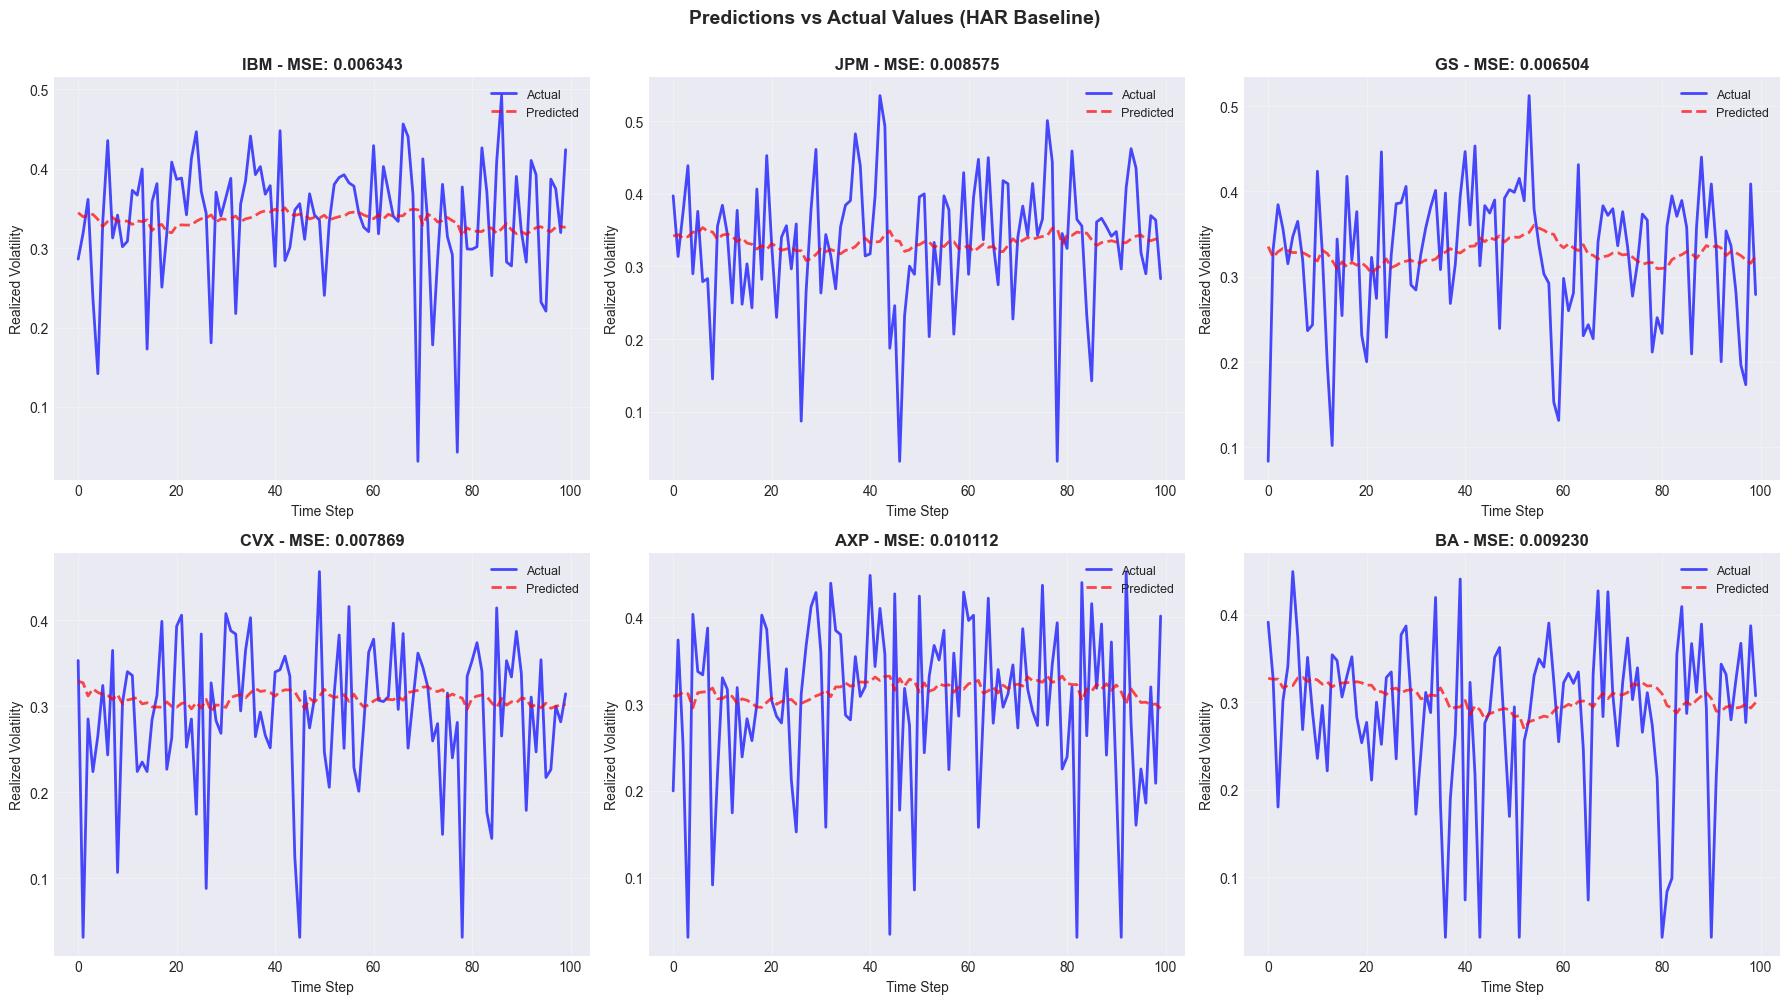


2. Plotting GHAR (True) predictions...


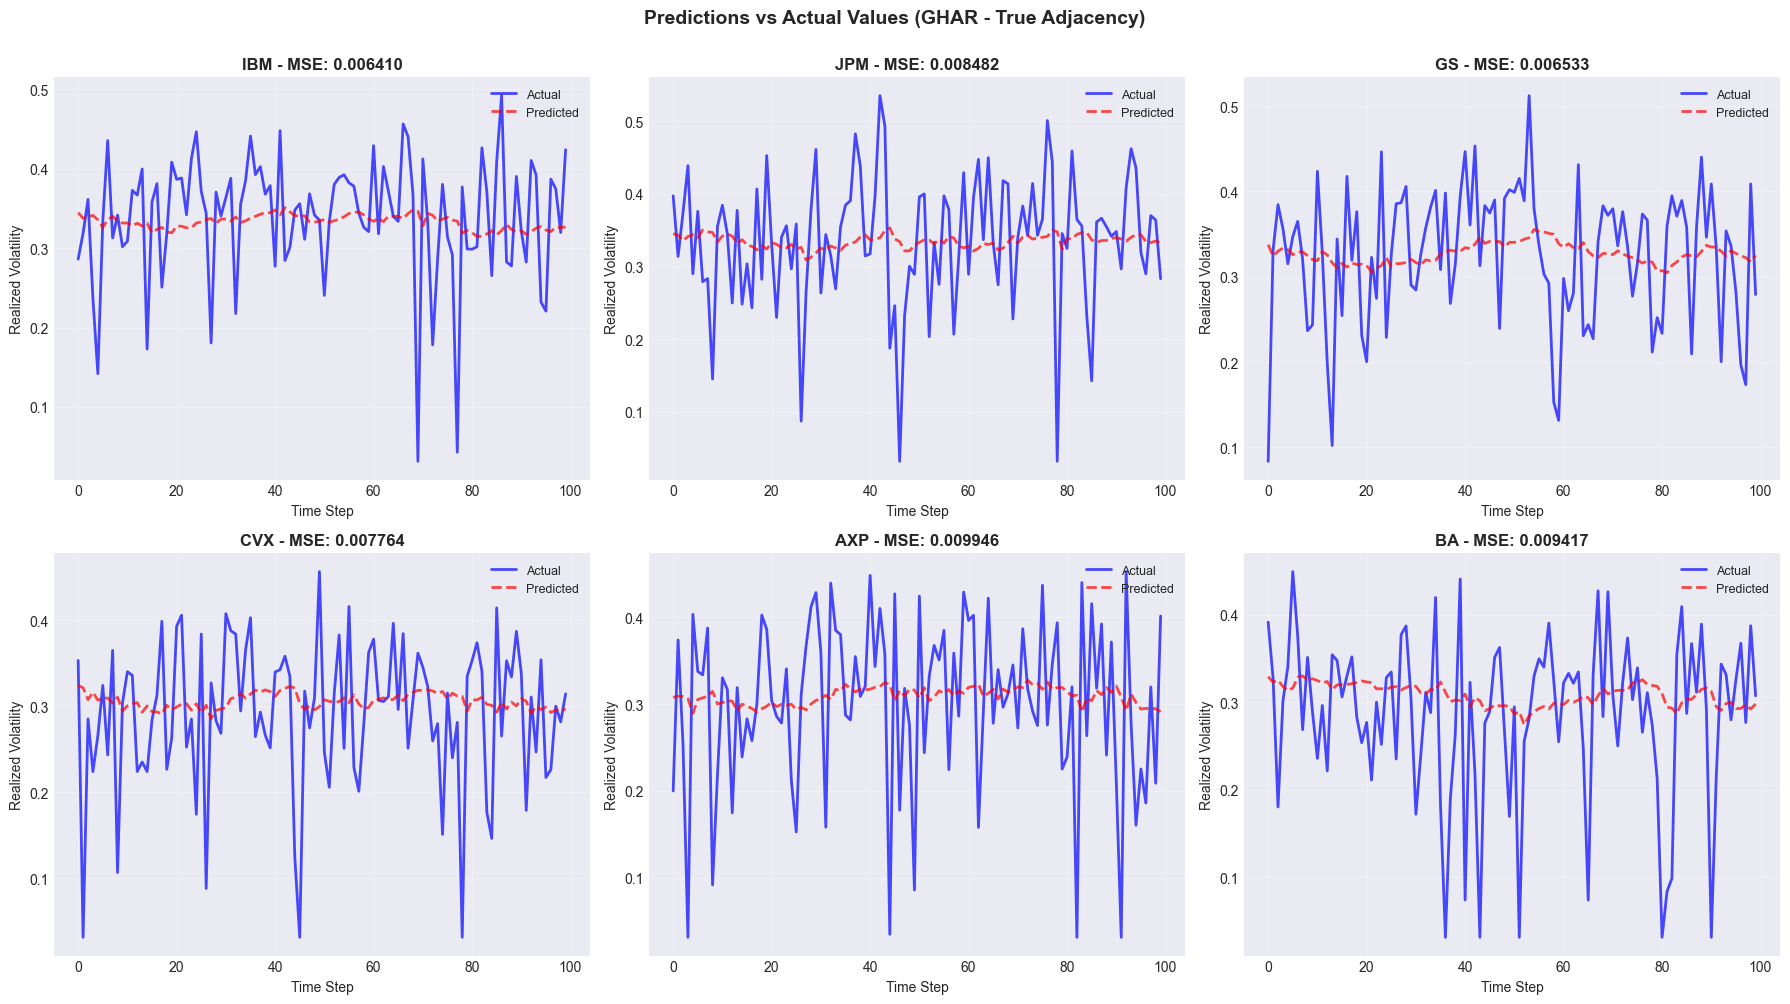


3. Plotting GHAR (GLASSO) predictions...


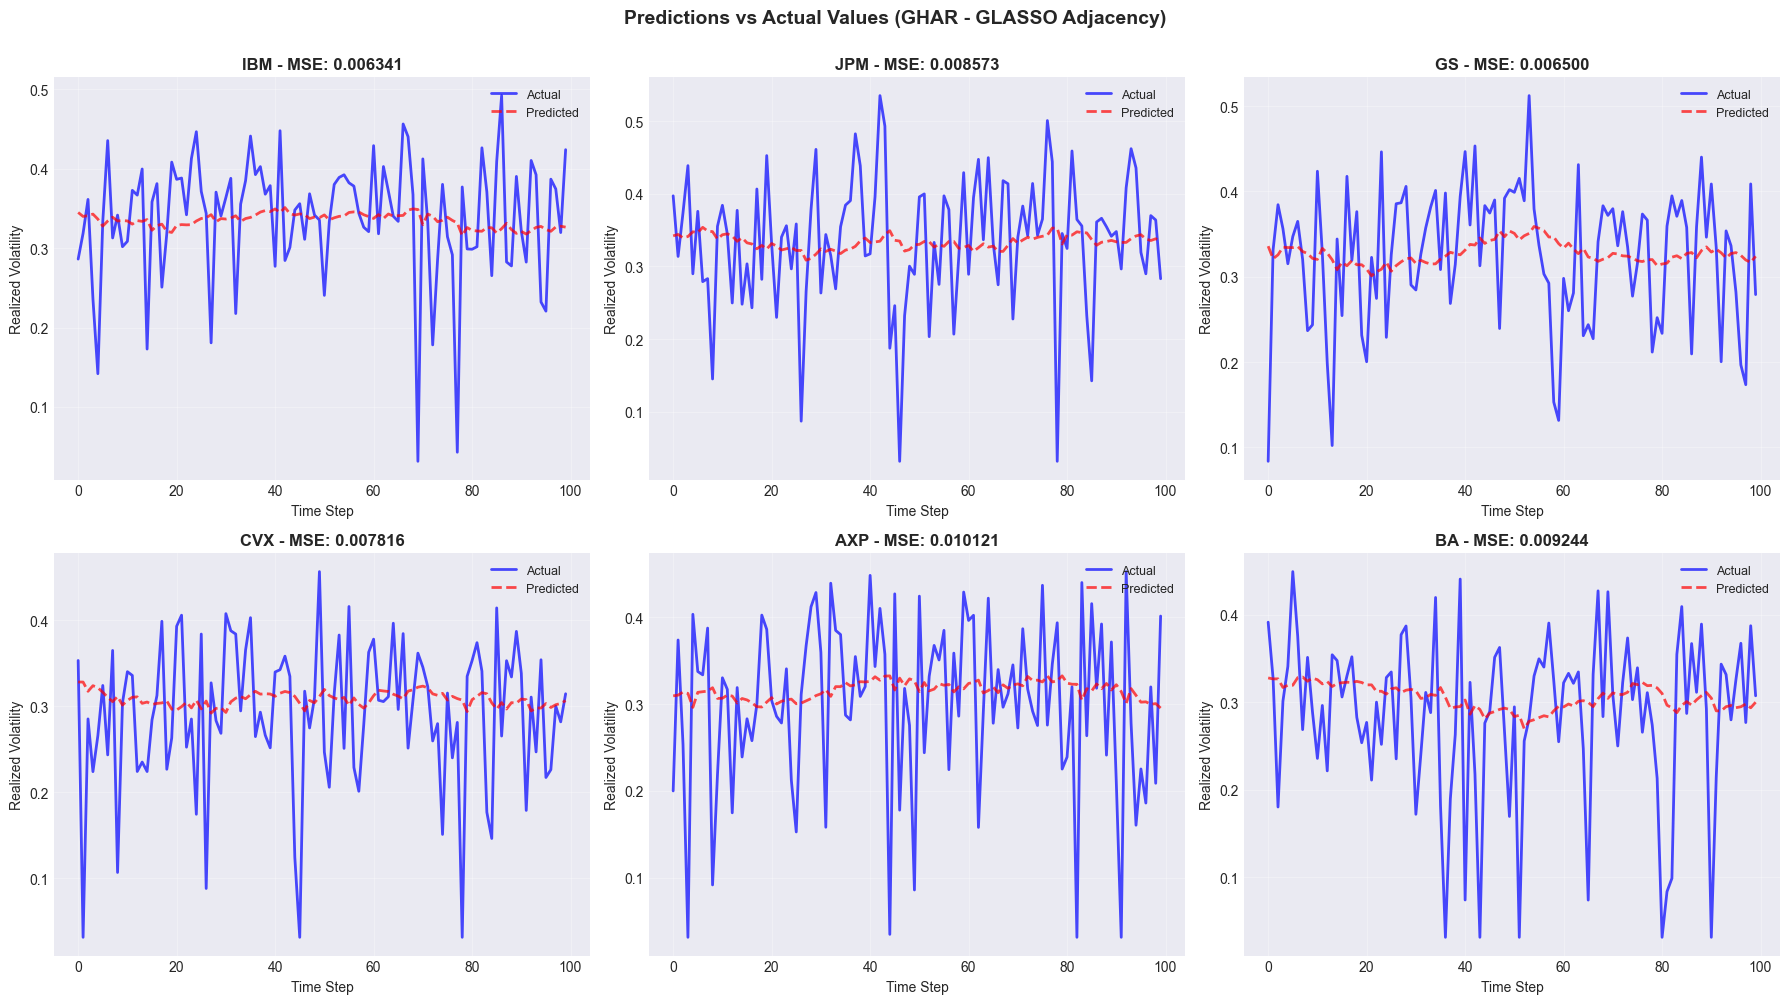


4. Plotting model comparison for IBM...


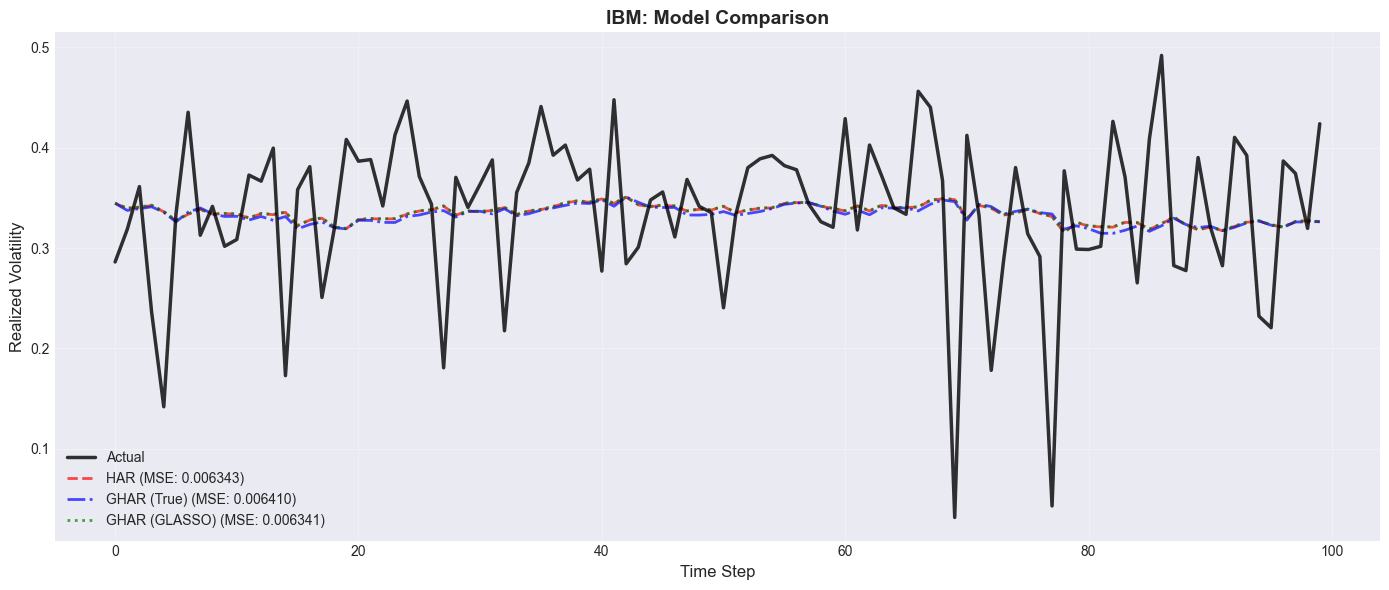


5. Plotting residuals for GHAR (True)...


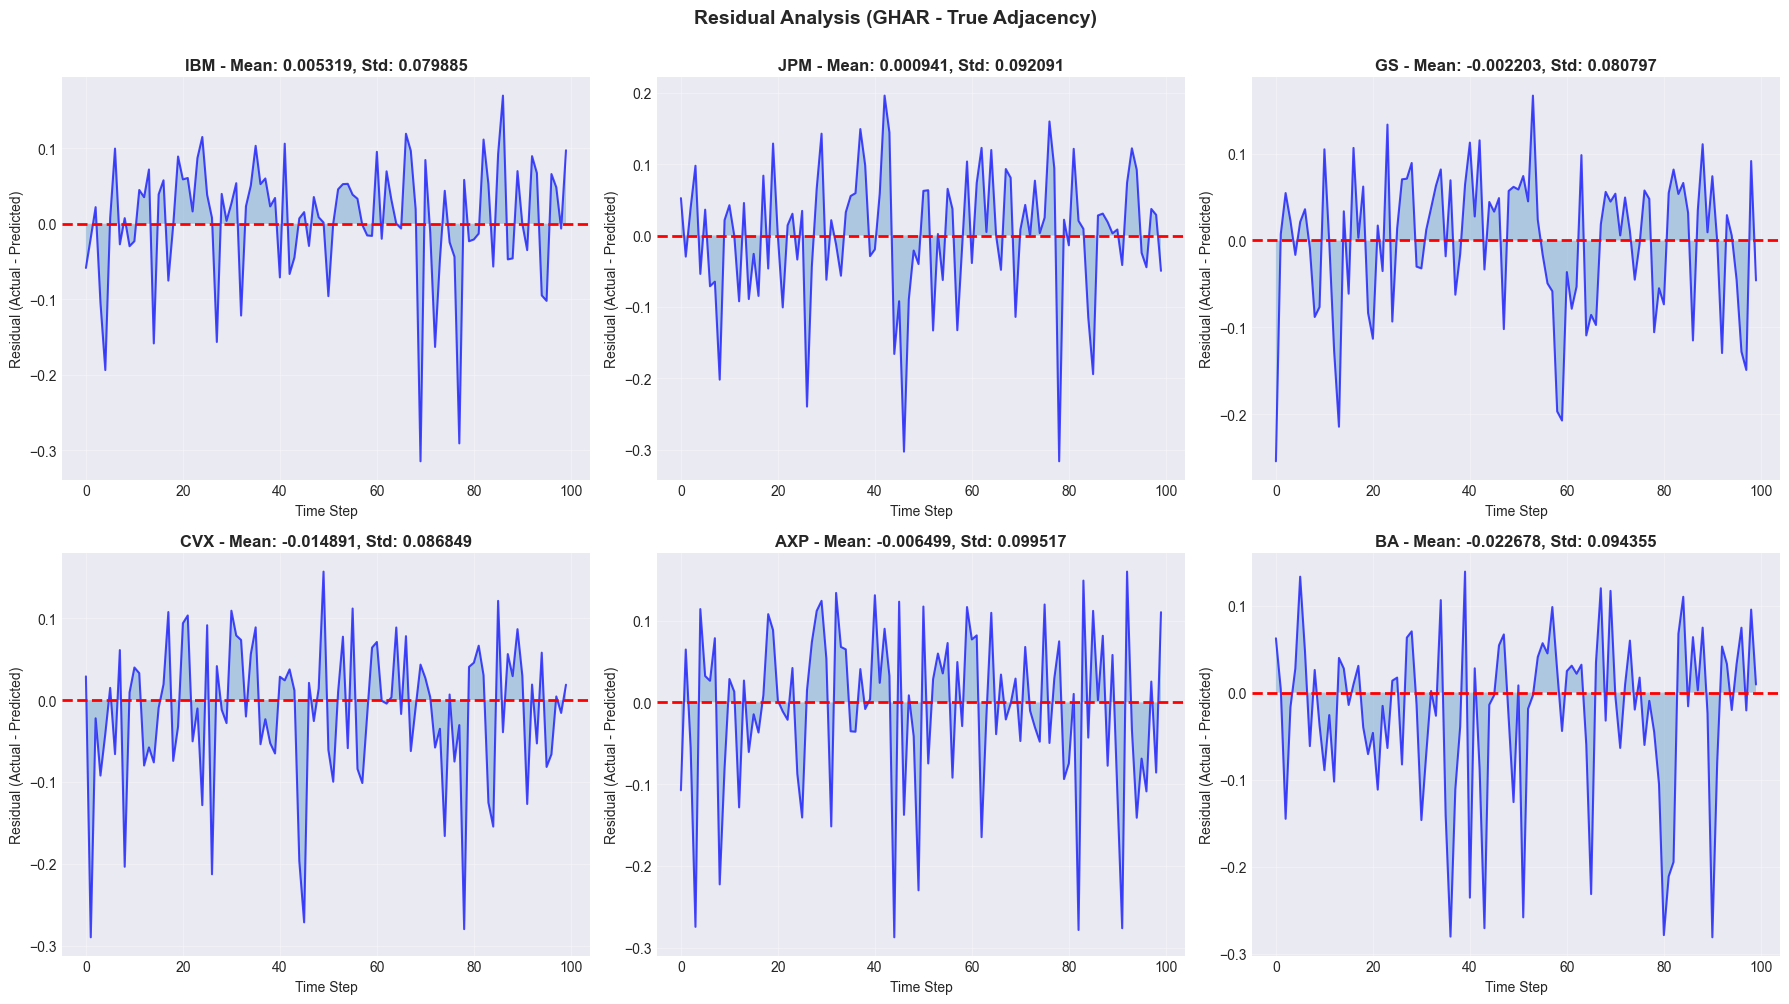


6. Plotting scatter (predicted vs actual) for GHAR (True)...


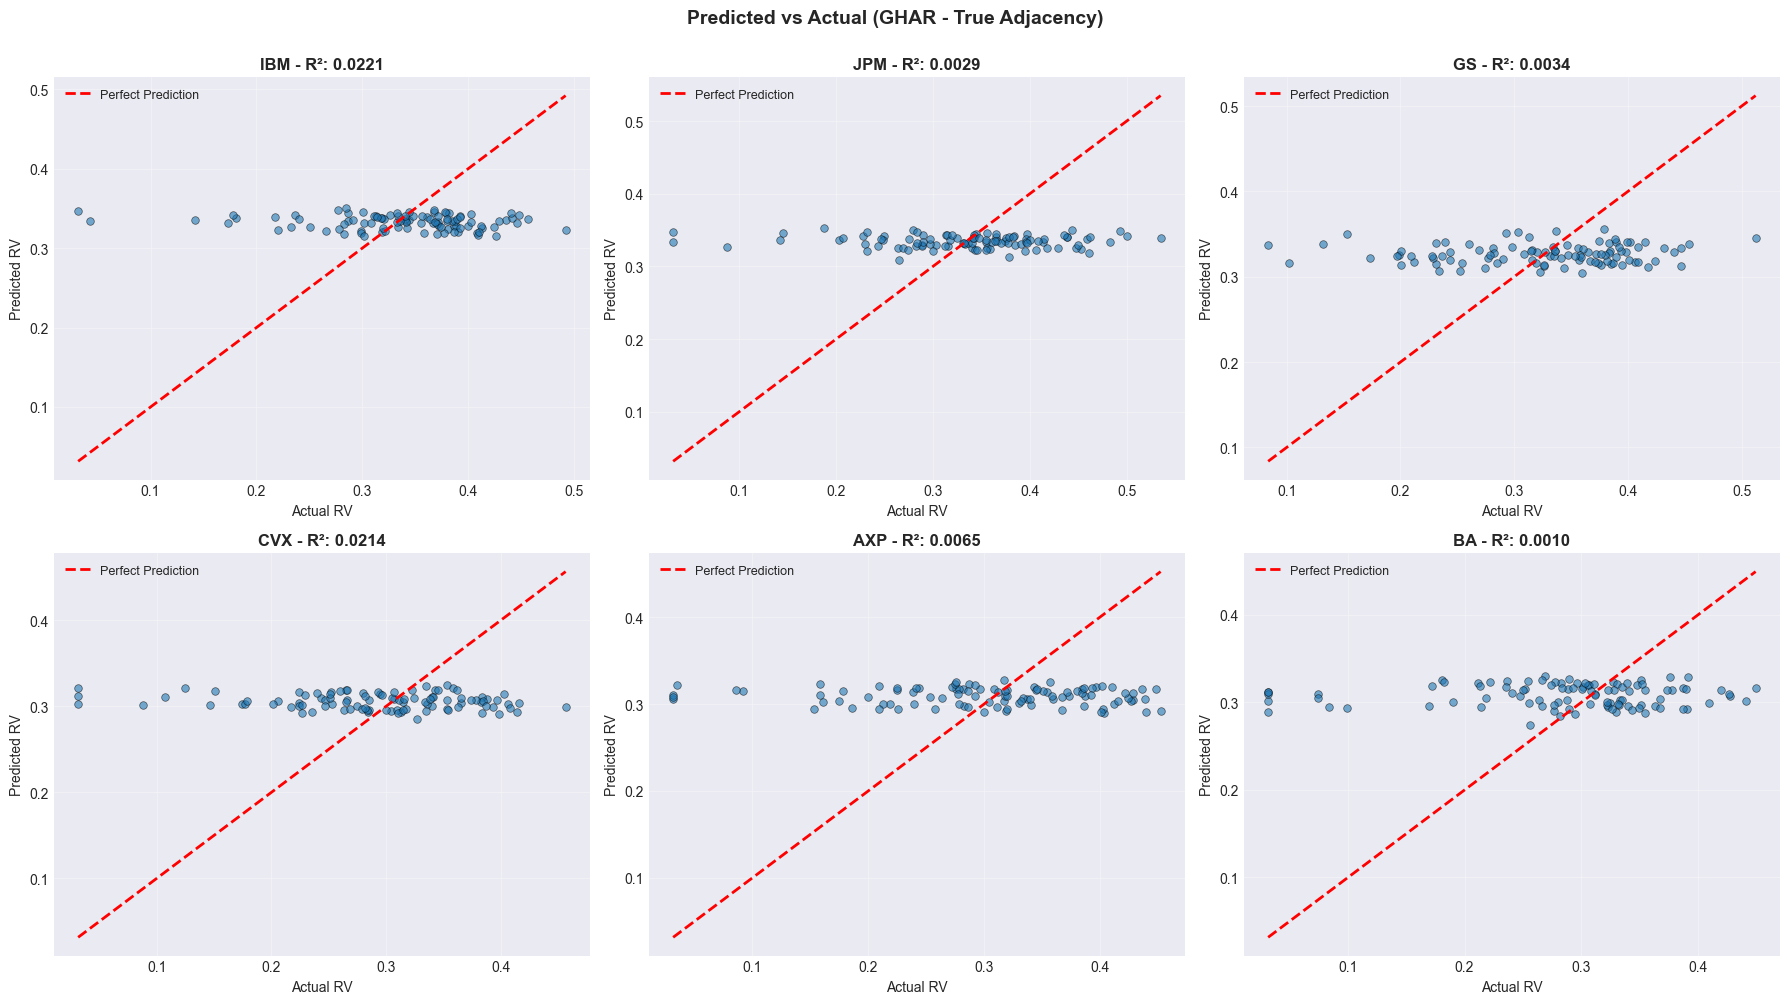


7. Plotting performance comparison...


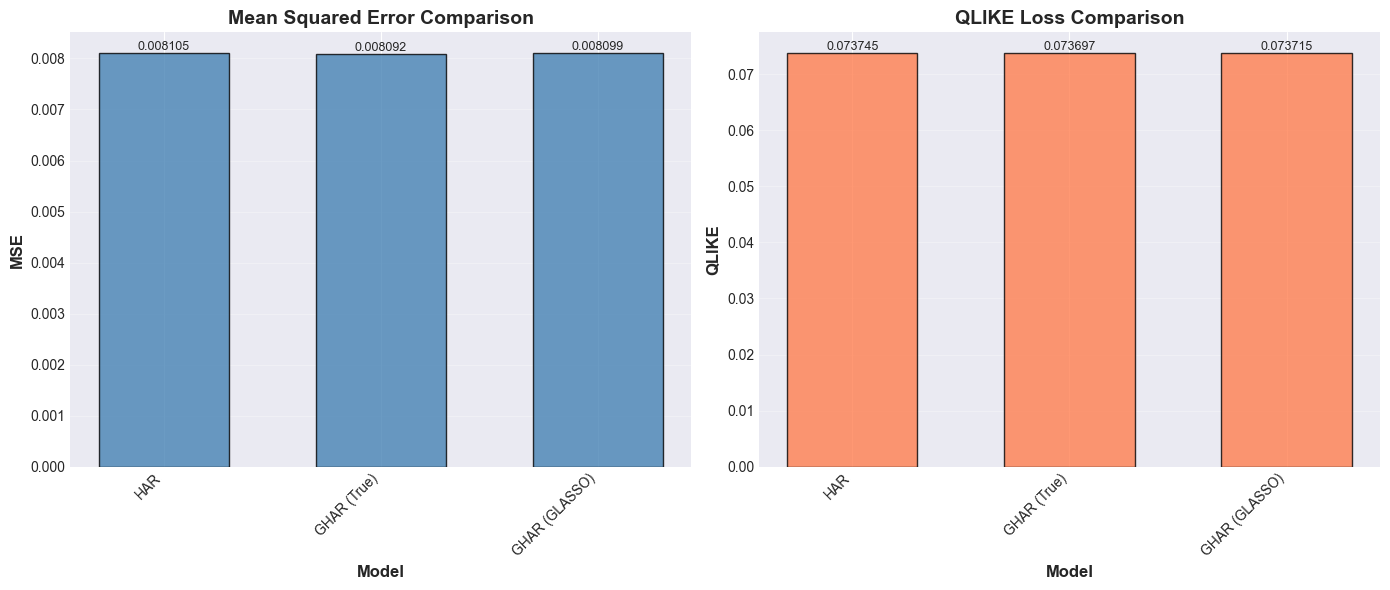


✓ All visualizations completed!


In [34]:
# Cell: Visualization of GHAR and GNNHAR Predictions
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\n" + "="*80)
print("VISUALIZATION: Model Predictions")
print("="*80)

# Set up matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# ==================== 1. Time Series Predictions for All Stocks ====================
def plot_predictions_by_stock(results_dict, stock_order, title_suffix=""):
    """
    Plot predictions vs actual values for each stock
    
    Args:
        results_dict: Dictionary containing 'pred_df' and 'true_df'
        stock_order: List of stock tickers
        title_suffix: Additional text for title
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    pred_df = results_dict['pred_df']
    true_df = results_dict['true_df']
    
    for idx, stock in enumerate(stock_order):
        ax = axes[idx]
        
        # Get data for this stock
        dates = pred_df.index
        true_vals = true_df.loc[dates, stock]
        pred_vals = pred_df[stock]
        
        # Plot
        ax.plot(range(len(dates)), true_vals, 'b-', label='Actual', linewidth=2, alpha=0.7)
        ax.plot(range(len(dates)), pred_vals, 'r--', label='Predicted', linewidth=2, alpha=0.7)
        
        # Calculate metrics for this stock
        mse_stock = np.mean((true_vals - pred_vals)**2)
        
        ax.set_title(f'{stock} - MSE: {mse_stock:.6f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Time Step', fontsize=10)
        ax.set_ylabel('Realized Volatility', fontsize=10)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Predictions vs Actual Values {title_suffix}', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    return fig

# Plot for HAR
print("\n1. Plotting HAR predictions...")
fig_har = plot_predictions_by_stock(results_har, STOCK_ORDER, "(HAR Baseline)")
plt.savefig('./data/mock/predictions_har.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot for GHAR (True)
print("\n2. Plotting GHAR (True) predictions...")
fig_ghar_true = plot_predictions_by_stock(results_ghar_true, STOCK_ORDER, "(GHAR - True Adjacency)")
plt.savefig('./data/mock/predictions_ghar_true.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot for GHAR (GLASSO)
print("\n3. Plotting GHAR (GLASSO) predictions...")
fig_ghar_glasso = plot_predictions_by_stock(results_ghar_glasso, STOCK_ORDER, "(GHAR - GLASSO Adjacency)")
plt.savefig('./data/mock/predictions_ghar_glasso.png', dpi=150, bbox_inches='tight')
plt.show()


# ==================== 2. Comparison Plot: All Models for One Stock ====================
def plot_model_comparison_single_stock(stock, models_dict, stock_order):
    """
    Compare all models for a single stock
    
    Args:
        stock: Stock ticker
        models_dict: Dictionary of {model_name: results_dict}
        stock_order: List of stock tickers
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Get true values (same for all models)
    first_model = list(models_dict.values())[0]
    dates = first_model['pred_df'].index
    true_vals = first_model['true_df'].loc[dates, stock]
    
    # Plot actual values
    ax.plot(range(len(dates)), true_vals, 'k-', label='Actual', 
            linewidth=2.5, alpha=0.8, zorder=10)
    
    # Plot predictions from each model
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    linestyles = ['--', '-.', ':', '--', '-.', ':']
    
    for idx, (model_name, results) in enumerate(models_dict.items()):
        pred_vals = results['pred_df'][stock]
        mse_stock = np.mean((true_vals - pred_vals)**2)
        
        ax.plot(range(len(dates)), pred_vals, 
                color=colors[idx % len(colors)], 
                linestyle=linestyles[idx % len(linestyles)],
                label=f'{model_name} (MSE: {mse_stock:.6f})', 
                linewidth=2, alpha=0.7)
    
    ax.set_title(f'{stock}: Model Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Realized Volatility', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Compare all linear models for IBM
print("\n4. Plotting model comparison for IBM...")
linear_models = {
    'HAR': results_har,
    'GHAR (True)': results_ghar_true,
    'GHAR (GLASSO)': results_ghar_glasso,
}
fig_ibm_comp = plot_model_comparison_single_stock('IBM', linear_models, STOCK_ORDER)
plt.savefig('./data/mock/comparison_ibm_linear.png', dpi=150, bbox_inches='tight')
plt.show()


# ==================== 3. Residual Analysis ====================
def plot_residuals(results_dict, stock_order, title_suffix=""):
    """
    Plot residuals (prediction errors) for each stock
    
    Args:
        results_dict: Dictionary containing 'pred_df' and 'true_df'
        stock_order: List of stock tickers
        title_suffix: Additional text for title
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    pred_df = results_dict['pred_df']
    true_df = results_dict['true_df']
    
    for idx, stock in enumerate(stock_order):
        ax = axes[idx]
        
        # Calculate residuals
        dates = pred_df.index
        true_vals = true_df.loc[dates, stock]
        pred_vals = pred_df[stock]
        residuals = true_vals - pred_vals
        
        # Plot residuals
        ax.plot(range(len(dates)), residuals, 'b-', linewidth=1.5, alpha=0.7)
        ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
        ax.fill_between(range(len(dates)), residuals, 0, alpha=0.3)
        
        # Statistics
        mean_res = np.mean(residuals)
        std_res = np.std(residuals)
        
        ax.set_title(f'{stock} - Mean: {mean_res:.6f}, Std: {std_res:.6f}', 
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Time Step', fontsize=10)
        ax.set_ylabel('Residual (Actual - Predicted)', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Residual Analysis {title_suffix}', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    return fig

# Plot residuals for GHAR (True)
print("\n5. Plotting residuals for GHAR (True)...")
fig_res_ghar = plot_residuals(results_ghar_true, STOCK_ORDER, "(GHAR - True Adjacency)")
plt.savefig('./data/mock/residuals_ghar_true.png', dpi=150, bbox_inches='tight')
plt.show()


# ==================== 4. Scatter Plot: Predicted vs Actual ====================
def plot_scatter_pred_vs_actual(results_dict, stock_order, title_suffix=""):
    """
    Scatter plot of predicted vs actual values for all stocks
    
    Args:
        results_dict: Dictionary containing 'pred_df' and 'true_df'
        stock_order: List of stock tickers
        title_suffix: Additional text for title
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    pred_df = results_dict['pred_df']
    true_df = results_dict['true_df']
    
    for idx, stock in enumerate(stock_order):
        ax = axes[idx]
        
        # Get data
        dates = pred_df.index
        true_vals = true_df.loc[dates, stock]
        pred_vals = pred_df[stock]
        
        # Scatter plot
        ax.scatter(true_vals, pred_vals, alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
        
        # Perfect prediction line
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        # Calculate R²
        correlation = np.corrcoef(true_vals, pred_vals)[0, 1]
        r_squared = correlation ** 2
        
        ax.set_title(f'{stock} - R²: {r_squared:.4f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Actual RV', fontsize=10)
        ax.set_ylabel('Predicted RV', fontsize=10)
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Predicted vs Actual {title_suffix}', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    return fig

# Scatter plot for GHAR (True)
print("\n6. Plotting scatter (predicted vs actual) for GHAR (True)...")
fig_scatter_ghar = plot_scatter_pred_vs_actual(results_ghar_true, STOCK_ORDER, "(GHAR - True Adjacency)")
plt.savefig('./data/mock/scatter_ghar_true.png', dpi=150, bbox_inches='tight')
plt.show()


# ==================== 5. Model Performance Comparison Bar Chart ====================
def plot_performance_comparison(models_dict):
    """
    Bar chart comparing MSE and QLIKE across models
    
    Args:
        models_dict: Dictionary of {model_name: results_dict}
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    model_names = list(models_dict.keys())
    mse_values = [results['mse'] for results in models_dict.values()]
    qlike_values = [results['qlike'] for results in models_dict.values()]
    
    x = np.arange(len(model_names))
    width = 0.6
    
    # MSE comparison
    bars1 = ax1.bar(x, mse_values, width, color='steelblue', alpha=0.8, edgecolor='black')
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('MSE', fontsize=12, fontweight='bold')
    ax1.set_title('Mean Squared Error Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=9)
    
    # QLIKE comparison
    bars2 = ax2.bar(x, qlike_values, width, color='coral', alpha=0.8, edgecolor='black')
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('QLIKE', fontsize=12, fontweight='bold')
    ax2.set_title('QLIKE Loss Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.6f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    return fig

# Performance comparison
print("\n7. Plotting performance comparison...")
all_models = {
    'HAR': results_har,
    'GHAR (True)': results_ghar_true,
    'GHAR (GLASSO)': results_ghar_glasso,
}
fig_perf = plot_performance_comparison(all_models)
plt.savefig('./data/mock/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("✓ All visualizations completed!")
print("="*80)


8. Plotting GNNHAR predictions...


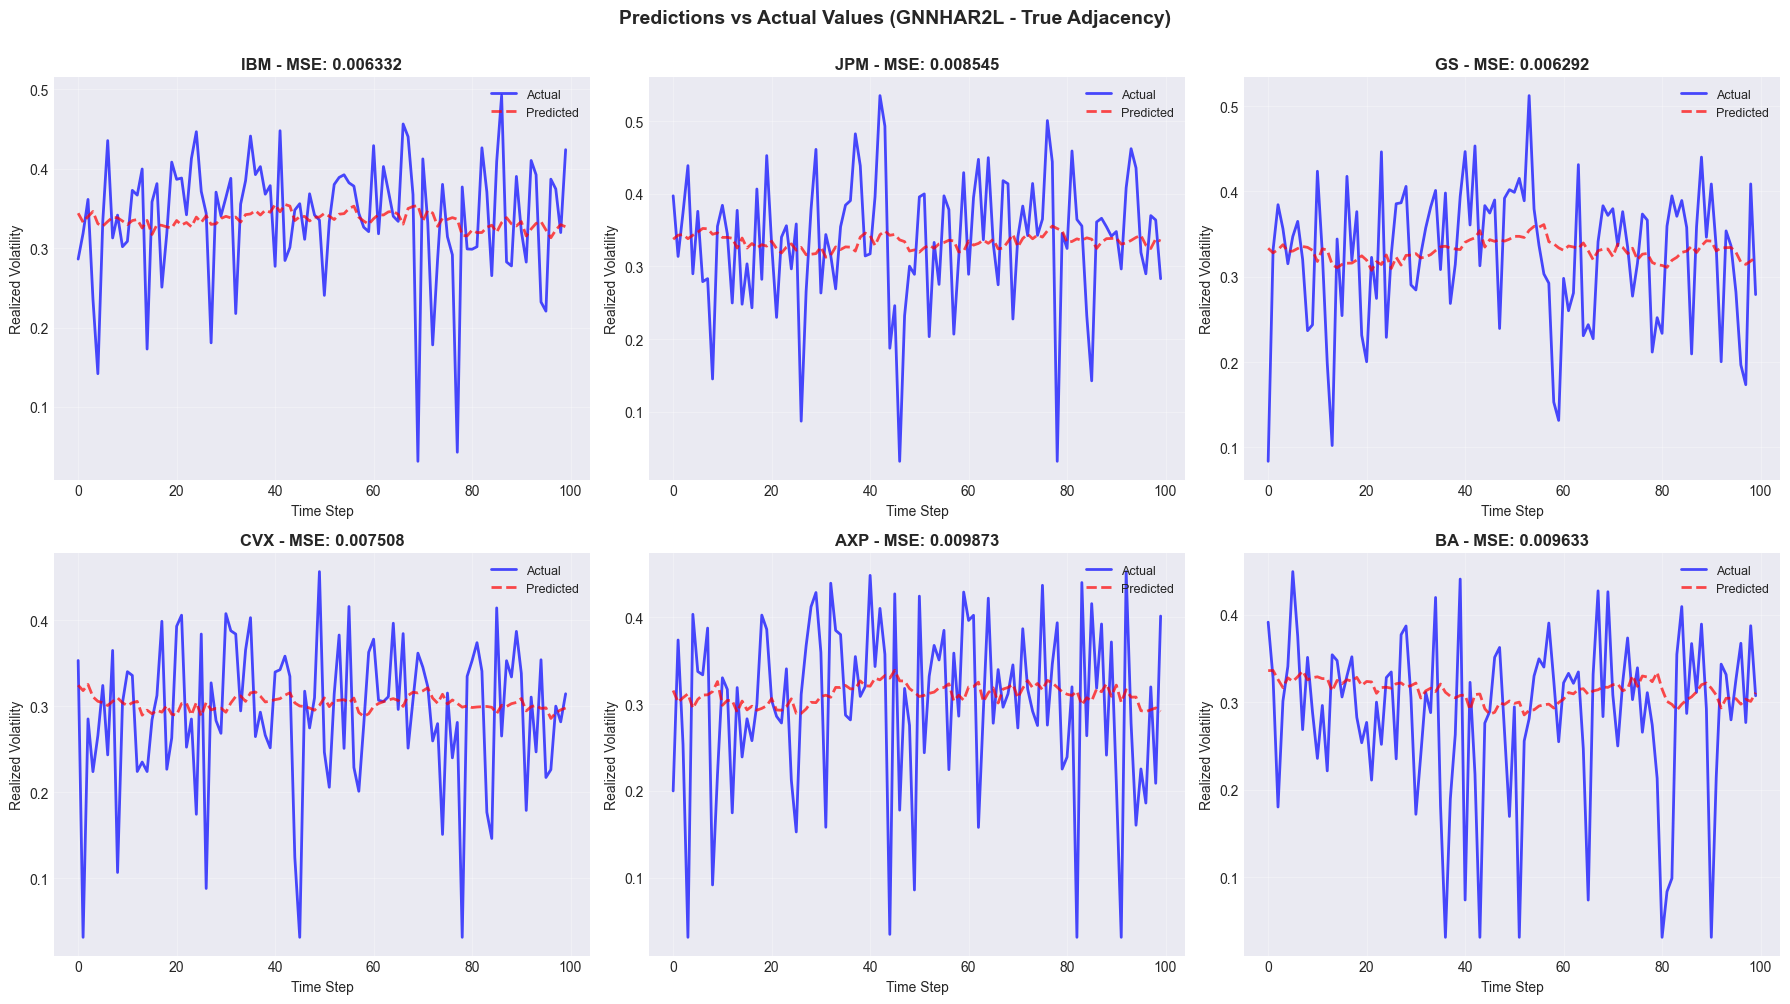


9. Comprehensive model comparison for IBM...


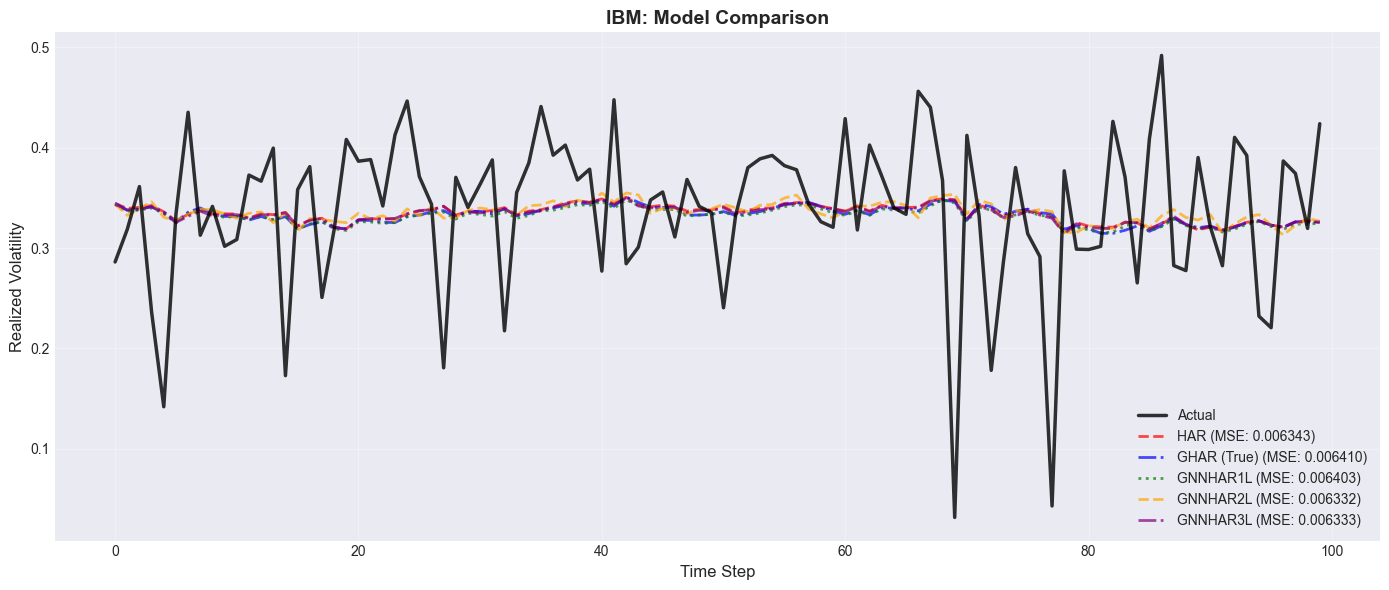


10. Plotting comprehensive performance comparison...


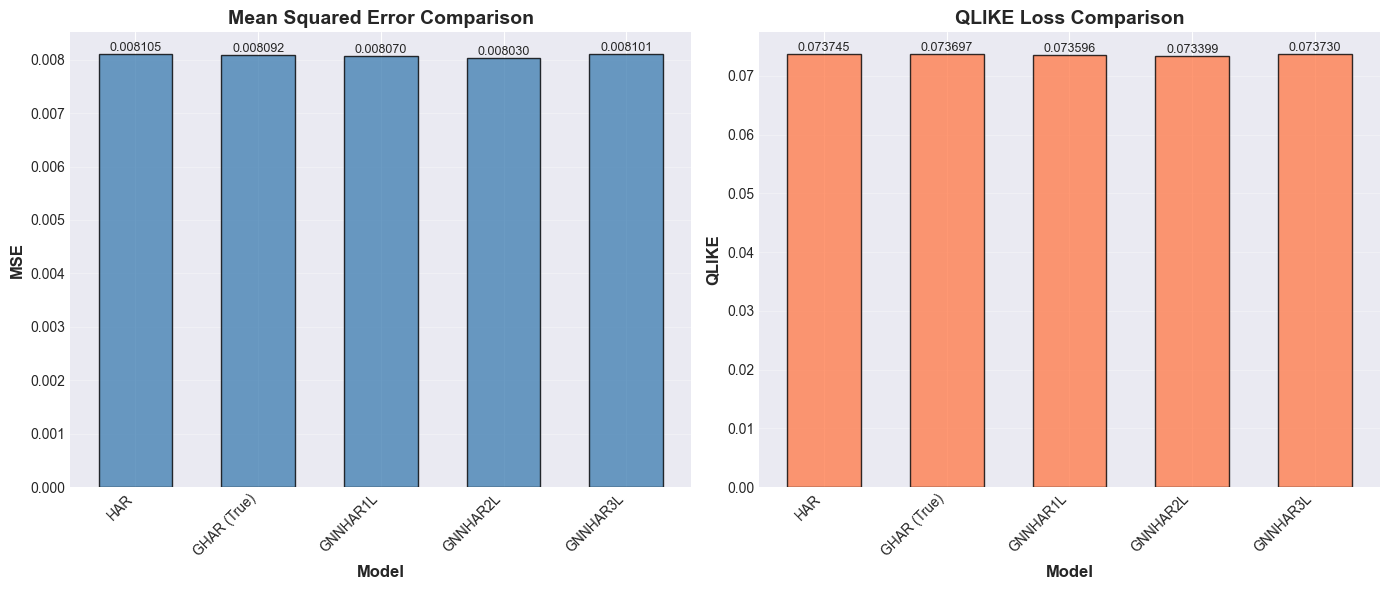

In [35]:
# ==================== 6. GNNHAR Predictions (if available) ====================
# Check if GNNHAR results exist
if 'results_gnnhar1l_true' in locals():
    print("\n8. Plotting GNNHAR predictions...")
    
    # Convert GNNHAR predictions to DataFrame format
    def gnnhar_to_df(results_gnn, test_dates, stock_order):
        """Convert GNNHAR results to DataFrame format"""
        pred_array = results_gnn['pred']  # (T, N)
        true_array = results_gnn['true']  # (T, N)
        
        pred_df = pd.DataFrame(pred_array, columns=stock_order, index=test_dates)
        true_df = pd.DataFrame(true_array, columns=stock_order, index=test_dates)
        
        return {'pred_df': pred_df, 'true_df': true_df, 
                'mse': results_gnn['mse'], 'qlike': results_gnn['qlike']}
    
    # Get test dates
    test_dates = [d for d in date_l if split_date <= d < test_end_date]
    
    # Convert GNNHAR results
    gnnhar1l_df = gnnhar_to_df(results_gnnhar1l_true, test_dates, STOCK_ORDER)
    gnnhar2l_df = gnnhar_to_df(results_gnnhar2l_true, test_dates, STOCK_ORDER)
    gnnhar3l_df = gnnhar_to_df(results_gnnhar3l_true, test_dates, STOCK_ORDER)
    
    # Plot GNNHAR2L (best model)
    fig_gnnhar2l = plot_predictions_by_stock(gnnhar2l_df, STOCK_ORDER, "(GNNHAR2L - True Adjacency)")
    plt.savefig('./data/mock/predictions_gnnhar2l_true.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Compare all models including GNNHAR
    print("\n9. Comprehensive model comparison for IBM...")
    all_models_with_gnn = {
        'HAR': results_har,
        'GHAR (True)': results_ghar_true,
        'GNNHAR1L': gnnhar1l_df,
        'GNNHAR2L': gnnhar2l_df,
        'GNNHAR3L': gnnhar3l_df,
    }
    fig_ibm_all = plot_model_comparison_single_stock('IBM', all_models_with_gnn, STOCK_ORDER)
    plt.savefig('./data/mock/comparison_ibm_all_models.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Performance comparison with GNNHAR
    print("\n10. Plotting comprehensive performance comparison...")
    fig_perf_all = plot_performance_comparison(all_models_with_gnn)
    plt.savefig('./data/mock/performance_comparison_all.png', dpi=150, bbox_inches='tight')
    plt.show()


11. Plotting training loss curves...


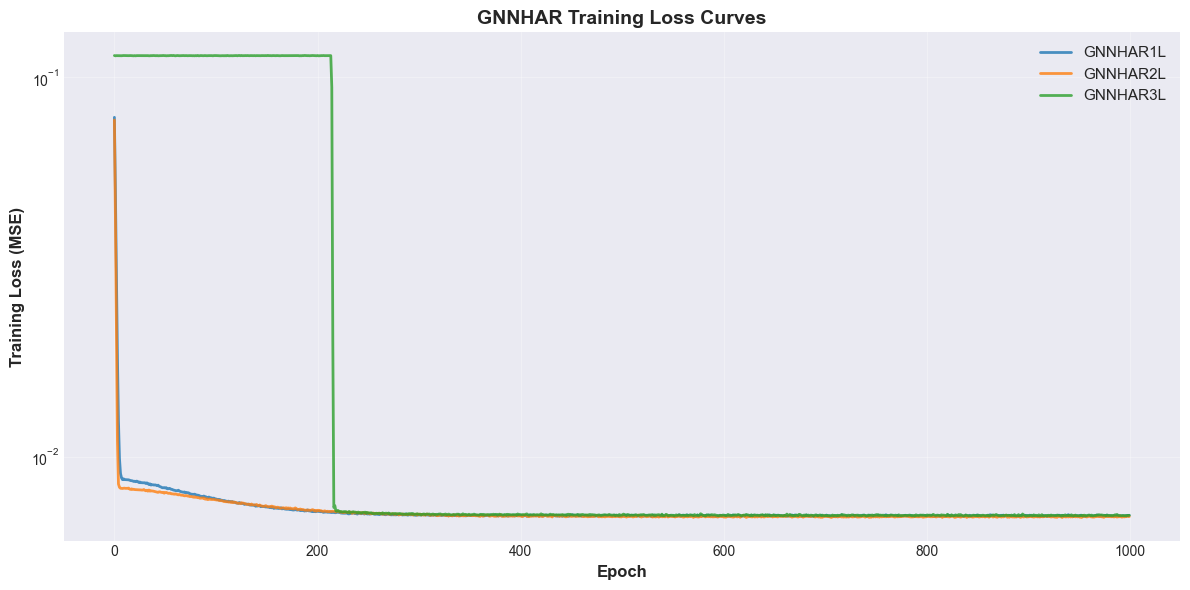

: 

In [ ]:
# ==================== 7. Training Loss Curves for GNNHAR ====================
if 'results_gnnhar1l_true' in locals():
    print("\n11. Plotting training loss curves...")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot training losses
    ax.plot(results_gnnhar1l_true['train_losses'], label='GNNHAR1L', linewidth=2, alpha=0.8)
    ax.plot(results_gnnhar2l_true['train_losses'], label='GNNHAR2L', linewidth=2, alpha=0.8)
    ax.plot(results_gnnhar3l_true['train_losses'], label='GNNHAR3L', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Training Loss (MSE)', fontsize=12, fontweight='bold')
    ax.set_title('GNNHAR Training Loss Curves', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')  # Log scale for better visualization
    
    plt.tight_layout()
    plt.savefig('./data/mock/training_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()